In [2]:
# ============================================================
# ROI Static 400-Point UE-Free Human Localization
# Digital Twin Prior Channel Difference + Multilateration
# 목표: 보행자 tracking path 주변 ROI에서 static localization 검증
# ============================================================

import mitsuba as mi
mi.set_variant("llvm_ad_mono_polarized")

import numpy as np
import time
import pickle
from scipy.optimize import minimize

from sionna.rt import (
    load_scene, Transmitter, Receiver, PlanarArray,
    PathSolver, RadioMaterial, SceneObject
)

# ============================================================
# Reproducibility
# ============================================================
np.random.seed(42)

c = 3e8
CARRIER_FREQ = 3.5e9  # 확인된 Sionna RT carrier frequency

# ============================================================
# STEP 1. Scene Load
# ============================================================
scene = load_scene("/home/yerim/Downloads/material_NEW_seongbuk(1).xml")

scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V"
)

scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V"
)

print(f"📡 Carrier frequency: {CARRIER_FREQ/1e9:.2f} GHz")

# ============================================================
# STEP 2. BS Deployment
# ============================================================
BS_Z = 50.0
TARGET_Z = 20.0

all_bs = [
    [270.370, -1631.474, BS_Z],
    [326.736, -1634.541, BS_Z],
    [311.936, -1662.765, BS_Z],
    [308.222, -1657.997, BS_Z],
    [192.678, -1676.419, BS_Z],
    [172.344, -1663.427, BS_Z],
    [229.612, -1714.744, BS_Z],
]

rx_offsets = [[1.0, 0.0]] * len(all_bs)

for i, (bp, offset) in enumerate(zip(all_bs, rx_offsets)):
    scene.add(
        Transmitter(
            f"tx{i+1}",
            position=bp
        )
    )

    scene.add(
        Receiver(
            f"rx{i+1}",
            position=[
                bp[0] + offset[0],
                bp[1] + offset[1],
                bp[2]
            ]
        )
    )

print(f"✅ BS {len(all_bs)}개 배치")

# ============================================================
# STEP 3. Human Material
# ============================================================
human_mat = RadioMaterial(
    "human",
    relative_permittivity=40.0,
    conductivity=0.8,
    scattering_coefficient=0.5,
    thickness=0.1
)

scene.add(human_mat)
solver = PathSolver()

# ============================================================
# STEP 4. Target Functions
# ============================================================
def add_target(x, y, z=TARGET_Z):
    """
    Static human target.
    z는 지면 높이.
    cuboid 중심을 z+0.85에 둬서 발이 지면에 닿도록 설정.
    """

    try:
        scene.edit(remove="target")
    except:
        pass

    box_mesh = mi.load_dict({
        "type": "cube",
        "to_world": (
            mi.ScalarTransform4f.translate([
                float(x),
                float(y),
                float(z + 0.85)
            ])
            @
            mi.ScalarTransform4f.scale([
                0.3,
                0.3,
                0.85
            ])
        )
    })

    target_obj = SceneObject(
        mi_mesh=box_mesh,
        name="target",
        radio_material=human_mat
    )

    scene.edit(add=target_obj)

    # Static 실험이므로 velocity는 0
    scene.get("target").velocity = [0.0, 0.0, 0.0]


def remove_target():
    try:
        scene.edit(remove="target")
    except:
        pass

# ============================================================
# STEP 5. H_prior Calculation
# ============================================================
print("\nH_prior 계산 중...")

remove_target()

paths_prior = solver(
    scene,
    synthetic_array=True,
    max_depth=3,
    los=True,
    specular_reflection=True,
    diffuse_reflection=False,
    seed=42
)

a_prior, tau_prior = paths_prior.cir(
    normalize_delays=False,
    out_type="numpy"
)

prior_dists_all = {}

for bs_idx in range(len(all_bs)):
    dists = set()

    for i in range(a_prior.shape[4]):
        t = float(tau_prior[bs_idx, bs_idx, i])

        if t > 0:
            dists.add(t * c / 2)

    prior_dists_all[bs_idx] = dists

print("✅ H_prior 완료")
print(f"✅ H_prior shape = {a_prior.shape}")

# ============================================================
# STEP 6. ROI Static Grid Definition
# ============================================================

# ============================================================
# ⭐ 수정 1:
# 전체 영역 대신 보행자 tracking path 주변 ROI로 제한
# tracking path 대략:
# x: 250 ~ 276
# y: -1670 ~ -1657
# ============================================================

x_range = np.linspace(240.0, 285.0, 20)
y_range = np.linspace(-1680.0, -1648.0, 20)

total_points = len(x_range) * len(y_range)

print(f"\n✅ ROI Static grid 생성 완료: {len(x_range)} x {len(y_range)} = {total_points} points")
print(f"   x range: {x_range[0]:.1f} ~ {x_range[-1]:.1f}")
print(f"   y range: {y_range[0]:.1f} ~ {y_range[-1]:.1f}")

# ============================================================
# STEP 7. Multilateration Initial Points
# ============================================================

# ============================================================
# ⭐ 수정 2:
# ROI 주변으로 초기값 범위 조정
# ============================================================

x_init = np.arange(235.0, 291.0, 10.0)
y_init = np.arange(-1685.0, -1643.0, 10.0)

init_points = [
    [x, y]
    for x in x_init
    for y in y_init
]

print(f"✅ Multilateration 초기값: {len(init_points)}개")

# ============================================================
# STEP 8. Parameters
# ============================================================

MIN_BS = 3

# ============================================================
# ⭐ 수정 3:
# 기존 0.5m보다 완화
# 너무 빡세면 유효 path가 줄어들 수 있음
# ============================================================

CLUTTER_THRESH = 1.0

MAX_RANGE_HORIZ = 120.0
AMP_THRESH = 1e-10

print(f"✅ MIN_BS = {MIN_BS}")
print(f"✅ CLUTTER_THRESH = {CLUTTER_THRESH} m")
print(f"✅ MAX_RANGE_HORIZ = {MAX_RANGE_HORIZ} m")

# ============================================================
# STEP 9. ROI Static 400-Point Localization
# ============================================================

dataset = []
errors = []
valid_bs_counts = []

t_start = time.time()
count = 0

print("\nROI Static 400-point localization 시작...")
print("=" * 70)

for x in x_range:
    for y in y_range:

        count += 1

        # ----------------------------------------------------
        # 1) Target 배치
        # ----------------------------------------------------
        add_target(x, y)

        # ----------------------------------------------------
        # 2) H_meas 계산
        # ----------------------------------------------------
        paths_meas = solver(
            scene,
            synthetic_array=True,
            max_depth=3,
            los=True,
            specular_reflection=True,
            diffuse_reflection=True,
            seed=42
        )

        a_meas, tau_meas = paths_meas.cir(
            normalize_delays=False,
            out_type="numpy"
        )

        doppler = np.array(paths_meas.doppler)

        # ----------------------------------------------------
        # 3) H_meas - H_prior 기반 신규 path 추출
        # ----------------------------------------------------
        ranges = []
        dopplers = []

        for bs_idx in range(len(all_bs)):

            bp = all_bs[bs_idx]
            dz_bs = abs(bp[2] - TARGET_Z)
            prior_dists = prior_dists_all[bs_idx]

            new_paths = []

            for i in range(a_meas.shape[4]):

                t = float(tau_meas[bs_idx, bs_idx, i])

                if t <= 0:
                    continue

                dist = t * c / 2

                a_m = float(
                    np.abs(a_meas)[
                        bs_idx,
                        0,
                        bs_idx,
                        0,
                        i,
                        0
                    ]
                )

                if a_m <= AMP_THRESH:
                    continue

                # ------------------------------------------------
                # 핵심 차분:
                # H_prior에 이미 있던 경로면 버림
                # H_prior에 없던 경로면 사람 때문에 생긴 new path로 판단
                # ------------------------------------------------
                is_new = not any(
                    abs(dist - pd) < CLUTTER_THRESH
                    for pd in prior_dists
                )

                if is_new:
                    try:
                        f_doppler = float(doppler[bs_idx, bs_idx, i])
                    except:
                        f_doppler = 0.0

                    new_paths.append(
                        (dist, a_m, f_doppler)
                    )

            # ------------------------------------------------
            # 4) Candidate path 선택
            # ------------------------------------------------
            if new_paths:

                # =================================================
                # ⭐ 수정 4:
                # Static localization에서는 shortest new path 사용
                # delay/range 기반 multilateration과 가장 직관적으로 맞음
                # =================================================
                best = min(new_paths, key=lambda v: v[0])

                if best[0] >= dz_bs:

                    r_horiz = np.sqrt(best[0]**2 - dz_bs**2)

                    if r_horiz > MAX_RANGE_HORIZ:
                        continue

                    ranges.append(
                        (bs_idx, r_horiz)
                    )

                    dopplers.append(best[2])

        valid_bs_counts.append(len(ranges))

        # ----------------------------------------------------
        # 5) Multilateration
        # ----------------------------------------------------
        pred_pos = None
        error = None
        best_cost = None

        if len(ranges) >= MIN_BS:

            bs_2d = np.array([
                [bp[0], bp[1]]
                for bp in all_bs
            ])

            def cost(p):
                return sum(
                    (
                        np.sqrt(
                            (p[0] - bs_2d[idx][0])**2 +
                            (p[1] - bs_2d[idx][1])**2
                        ) - r
                    )**2
                    for idx, r in ranges
                )

            best_result = None
            best_cost_val = float("inf")

            for x0 in init_points:

                result = minimize(
                    cost,
                    x0,
                    method="Nelder-Mead",
                    options={
                        "xatol": 0.01,
                        "fatol": 0.01,
                        "maxiter": 10000
                    }
                )

                if result.fun < best_cost_val:
                    best_cost_val = result.fun
                    best_result = result

            pred_pos = best_result.x.tolist()
            best_cost = float(best_cost_val)

            error = float(
                np.sqrt(
                    (pred_pos[0] - x)**2 +
                    (pred_pos[1] - y)**2
                )
            )

            errors.append(error)

        # ----------------------------------------------------
        # 6) Doppler summary
        # ----------------------------------------------------
        if dopplers:
            speed_per_bs = [
                abs(d) * c / (2 * CARRIER_FREQ)
                for d in dopplers
            ]

            est_speed = float(np.median(speed_per_bs))
            avg_abs_doppler = float(
                np.mean([abs(d) for d in dopplers])
            )
        else:
            est_speed = 0.0
            avg_abs_doppler = 0.0

        # ----------------------------------------------------
        # 7) Save sample
        # ----------------------------------------------------
        dataset.append({
            "true_position": [float(x), float(y)],
            "pred_position": pred_pos,
            "error": error,
            "n_valid_bs": len(ranges),
            "ranges": [
                (int(idx), float(r))
                for idx, r in ranges
            ],
            "avg_abs_doppler": avg_abs_doppler,
            "est_speed_from_doppler": est_speed,
            "best_cost": best_cost
        })

        # ----------------------------------------------------
        # 8) Progress print & intermediate save
        # ----------------------------------------------------
        elapsed = time.time() - t_start
        eta = (elapsed / count) * (total_points - count)

        print(
            f"{count:3d}/{total_points} | "
            f"valid BS={len(ranges)} | "
            f"error={error if error is not None else 'None'} | "
            f"elapsed={elapsed/60:.1f}min | "
            f"ETA={eta/60:.1f}min",
            end="\r"
        )

        if count % 50 == 0:
            with open("/home/yerim/isac_static_roi_400_result_partial.pkl", "wb") as f:
                pickle.dump({
                    "dataset": dataset,
                    "errors": errors,
                    "valid_bs_counts": valid_bs_counts,
                    "all_bs": all_bs,
                    "BS_Z": BS_Z,
                    "TARGET_Z": TARGET_Z,
                    "x_range": x_range.tolist(),
                    "y_range": y_range.tolist(),
                    "CARRIER_FREQ": CARRIER_FREQ,
                    "MIN_BS": MIN_BS,
                    "CLUTTER_THRESH": CLUTTER_THRESH,
                    "MAX_RANGE_HORIZ": MAX_RANGE_HORIZ,
                    "path_selection": "shortest_new_path",
                    "experiment": "ROI Static 400"
                }, f)

            print(f"\n💾 중간 저장 완료: {count}/{total_points}")

# ============================================================
# STEP 10. Final Save & Statistics
# ============================================================

elapsed_total = time.time() - t_start

errors_np = np.array(errors)
valid_bs_np = np.array(valid_bs_counts)

with open("/home/yerim/isac_static_roi_400_result.pkl", "wb") as f:
    pickle.dump({
        "dataset": dataset,
        "errors": errors,
        "valid_bs_counts": valid_bs_counts,
        "all_bs": all_bs,
        "BS_Z": BS_Z,
        "TARGET_Z": TARGET_Z,
        "x_range": x_range.tolist(),
        "y_range": y_range.tolist(),
        "CARRIER_FREQ": CARRIER_FREQ,
        "MIN_BS": MIN_BS,
        "CLUTTER_THRESH": CLUTTER_THRESH,
        "MAX_RANGE_HORIZ": MAX_RANGE_HORIZ,
        "path_selection": "shortest_new_path",
        "experiment": "ROI Static 400"
    }, f)

print("\n\n" + "=" * 70)
print("ROI Static 400-point Localization 결과")
print("=" * 70)

print(f"총 grid point:       {total_points}")
print(f"유효 샘플:           {len(errors_np)}/{total_points}")
print(f"유효 샘플 비율:      {len(errors_np)/total_points*100:.1f}%")
print(f"평균 유효 BS 수:     {np.mean(valid_bs_np):.2f}개")
print(f"중앙값 유효 BS 수:   {np.median(valid_bs_np):.1f}개")

if len(errors_np) > 0:
    print(f"\n평균 오차:           {np.mean(errors_np):.2f} m")
    print(f"중앙값 오차:         {np.median(errors_np):.2f} m")
    print(f"RMSE:                {np.sqrt(np.mean(errors_np**2)):.2f} m")
    print(f"P90 오차:            {np.percentile(errors_np, 90):.2f} m")
    print(f"최대 오차:           {np.max(errors_np):.2f} m")

    print(f"\n< 1m 비율:           {np.mean(errors_np < 1.0)*100:.1f}%")
    print(f"< 2m 비율:           {np.mean(errors_np < 2.0)*100:.1f}%")
    print(f"< 5m 비율:           {np.mean(errors_np < 5.0)*100:.1f}%")
    print(f"< 10m 비율:          {np.mean(errors_np < 10.0)*100:.1f}%")

else:
    print("\n⚠️ 유효 샘플이 없습니다. MIN_BS 또는 CLUTTER_THRESH 조정 필요")

print(f"\n총 소요 시간:        {elapsed_total/60:.1f}분")
print("✅ 저장 완료: /home/yerim/isac_static_roi_400_result.pkl")

📡 Carrier frequency: 3.50 GHz
✅ BS 7개 배치

H_prior 계산 중...
✅ H_prior 완료
✅ H_prior shape = (7, 1, 7, 1, 20, 1)

✅ ROI Static grid 생성 완료: 20 x 20 = 400 points
   x range: 240.0 ~ 285.0
   y range: -1680.0 ~ -1648.0
✅ Multilateration 초기값: 30개
✅ MIN_BS = 3
✅ CLUTTER_THRESH = 1.0 m
✅ MAX_RANGE_HORIZ = 120.0 m

ROI Static 400-point localization 시작...
 50/400 | valid BS=4 | error=1.4297682721361267 | elapsed=2.9min | ETA=20.6min
💾 중간 저장 완료: 50/400
100/400 | valid BS=5 | error=0.035510433930001466 | elapsed=5.9min | ETA=17.6min
💾 중간 저장 완료: 100/400
150/400 | valid BS=4 | error=0.32928437612388795 | elapsed=8.8min | ETA=14.6min
💾 중간 저장 완료: 150/400
200/400 | valid BS=6 | error=1.4452135359421585 | elapsed=11.7min | ETA=11.7min
💾 중간 저장 완료: 200/400
250/400 | valid BS=4 | error=1.1122460560146914 | elapsed=14.7min | ETA=8.8minn
💾 중간 저장 완료: 250/400
300/400 | valid BS=5 | error=2.392165954371961 | elapsed=17.6min | ETA=5.9minnn
💾 중간 저장 완료: 300/400
350/400 | valid BS=4 | error=0.9098658148100331 | elaps

In [3]:
import pickle
import numpy as np

with open("/home/yerim/isac_static_roi_400_result.pkl", "rb") as f:
    data = pickle.load(f)

dataset = data["dataset"]

valid = [d for d in dataset if d["error"] is not None]
valid_sorted = sorted(valid, key=lambda d: d["error"], reverse=True)

print("Top 10 worst errors")
for i, d in enumerate(valid_sorted[:10]):
    print(f"{i+1}: true={d['true_position']}, pred={d['pred_position']}, "
          f"error={d['error']:.2f}m, valid BS={d['n_valid_bs']}, "
          f"ranges={d['ranges']}")

Top 10 worst errors
1: true=[266.05263157894734, -1661.4736842105262], pred=[253.85007134620056, -1712.7223720133002], error=52.68m, valid BS=3, ranges=[(2, 76.63913199927745), (4, 73.84559643057992), (5, 92.55056162002086)]
2: true=[240.0, -1663.157894736842], pred=[227.33298110654238, -1642.7523254720936], error=24.02m, valid BS=3, ranges=[(2, 100.80036053301008), (3, 68.01802385197682), (4, 47.53744333454436)]
3: true=[244.73684210526315, -1678.3157894736842], pred=[234.4565315258302, -1675.2642798459642], error=10.72m, valid BS=3, ranges=[(0, 52.53302928956297), (1, 103.4236152883352), (6, 37.62163864661916)]
4: true=[273.1578947368421, -1671.578947368421], pred=[272.57752940452326, -1665.2955335847391], error=6.31m, valid BS=3, ranges=[(2, 39.11623225164011), (3, 36.506696373931575), (5, 100.047589157835)]
5: true=[266.05263157894734, -1668.2105263157894], pred=[264.66830867264923, -1662.5409140394347], error=5.84m, valid BS=4, ranges=[(2, 48.06513261426634), (3, 42.57959427406840

In [4]:
# ============================================================
# ROI Static 400-Point UE-Free Human Localization
# Bounded Optimization Version
# Digital Twin Prior Channel Difference + Multilateration
# ============================================================

import mitsuba as mi
mi.set_variant("llvm_ad_mono_polarized")

import numpy as np
import time
import pickle
from scipy.optimize import minimize

from sionna.rt import (
    load_scene, Transmitter, Receiver, PlanarArray,
    PathSolver, RadioMaterial, SceneObject
)

# ============================================================
# Reproducibility
# ============================================================
np.random.seed(42)

c = 3e8
CARRIER_FREQ = 3.5e9

# ============================================================
# STEP 1. Scene Load
# ============================================================
scene = load_scene("/home/yerim/Downloads/material_NEW_seongbuk(1).xml")

scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V"
)

scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V"
)

print(f"📡 Carrier frequency: {CARRIER_FREQ/1e9:.2f} GHz")

# ============================================================
# STEP 2. BS Deployment
# ============================================================
BS_Z = 50.0
TARGET_Z = 20.0

all_bs = [
    [270.370, -1631.474, BS_Z],
    [326.736, -1634.541, BS_Z],
    [311.936, -1662.765, BS_Z],
    [308.222, -1657.997, BS_Z],
    [192.678, -1676.419, BS_Z],
    [172.344, -1663.427, BS_Z],
    [229.612, -1714.744, BS_Z],
]

rx_offsets = [[1.0, 0.0]] * len(all_bs)

for i, (bp, offset) in enumerate(zip(all_bs, rx_offsets)):
    scene.add(Transmitter(f"tx{i+1}", position=bp))
    scene.add(
        Receiver(
            f"rx{i+1}",
            position=[bp[0] + offset[0], bp[1] + offset[1], bp[2]]
        )
    )

print(f"✅ BS {len(all_bs)}개 배치")

# ============================================================
# STEP 3. Human Material
# ============================================================
human_mat = RadioMaterial(
    "human",
    relative_permittivity=40.0,
    conductivity=0.8,
    scattering_coefficient=0.5,
    thickness=0.1
)

scene.add(human_mat)
solver = PathSolver()

# ============================================================
# STEP 4. Target Functions
# ============================================================
def add_target(x, y, z=TARGET_Z):
    """
    Static human target.
    z는 지면 높이.
    cuboid 중심을 z+0.85에 둬서 발이 지면에 닿도록 설정.
    """
    try:
        scene.edit(remove="target")
    except:
        pass

    box_mesh = mi.load_dict({
        "type": "cube",
        "to_world": (
            mi.ScalarTransform4f.translate([
                float(x),
                float(y),
                float(z + 0.85)
            ])
            @
            mi.ScalarTransform4f.scale([
                0.3,
                0.3,
                0.85
            ])
        )
    })

    target_obj = SceneObject(
        mi_mesh=box_mesh,
        name="target",
        radio_material=human_mat
    )

    scene.edit(add=target_obj)

    # Static 실험이므로 velocity는 0
    scene.get("target").velocity = [0.0, 0.0, 0.0]


def remove_target():
    try:
        scene.edit(remove="target")
    except:
        pass

# ============================================================
# STEP 5. H_prior Calculation
# ============================================================
print("\nH_prior 계산 중...")

remove_target()

paths_prior = solver(
    scene,
    synthetic_array=True,
    max_depth=3,
    los=True,
    specular_reflection=True,
    diffuse_reflection=False,
    seed=42
)

a_prior, tau_prior = paths_prior.cir(
    normalize_delays=False,
    out_type="numpy"
)

prior_dists_all = {}

for bs_idx in range(len(all_bs)):
    dists = set()

    for i in range(a_prior.shape[4]):
        t = float(tau_prior[bs_idx, bs_idx, i])

        if t > 0:
            dists.add(t * c / 2)

    prior_dists_all[bs_idx] = dists

print("✅ H_prior 완료")
print(f"✅ H_prior shape = {a_prior.shape}")

# ============================================================
# STEP 6. ROI Static Grid Definition
# ============================================================

# 보행자 tracking path 주변 ROI
x_range = np.linspace(240.0, 285.0, 20)
y_range = np.linspace(-1680.0, -1648.0, 20)

total_points = len(x_range) * len(y_range)

print(f"\n✅ ROI Static grid 생성 완료: {len(x_range)} x {len(y_range)} = {total_points} points")
print(f"   x range: {x_range[0]:.1f} ~ {x_range[-1]:.1f}")
print(f"   y range: {y_range[0]:.1f} ~ {y_range[-1]:.1f}")

# ============================================================
# STEP 7. Multilateration Initial Points
# ============================================================

x_init = np.arange(235.0, 291.0, 10.0)
y_init = np.arange(-1685.0, -1643.0, 10.0)

init_points = [
    [x, y]
    for x in x_init
    for y in y_init
]

print(f"✅ Multilateration 초기값: {len(init_points)}개")

# ============================================================
# STEP 8. Parameters
# ============================================================

MIN_BS = 3
CLUTTER_THRESH = 1.0
MAX_RANGE_HORIZ = 120.0
AMP_THRESH = 1e-10

# ============================================================
# ⭐ 핵심 수정: 위치 추정 bound
# ROI 밖으로 예측 위치가 튀지 않도록 제한
# ============================================================
BOUNDS = [
    (float(x_range[0]), float(x_range[-1])),
    (float(y_range[0]), float(y_range[-1]))
]

print(f"✅ MIN_BS = {MIN_BS}")
print(f"✅ CLUTTER_THRESH = {CLUTTER_THRESH} m")
print(f"✅ MAX_RANGE_HORIZ = {MAX_RANGE_HORIZ} m")
print(f"✅ Bounds = {BOUNDS}")

# ============================================================
# STEP 9. ROI Static 400-Point Localization
# ============================================================

dataset = []
errors = []
valid_bs_counts = []

t_start = time.time()
count = 0

print("\nROI Static 400-point localization 시작 (Bounded Optimization)...")
print("=" * 70)

for x in x_range:
    for y in y_range:

        count += 1

        # ----------------------------------------------------
        # 1) Target 배치
        # ----------------------------------------------------
        add_target(x, y)

        # ----------------------------------------------------
        # 2) H_meas 계산
        # ----------------------------------------------------
        paths_meas = solver(
            scene,
            synthetic_array=True,
            max_depth=3,
            los=True,
            specular_reflection=True,
            diffuse_reflection=True,
            seed=42
        )

        a_meas, tau_meas = paths_meas.cir(
            normalize_delays=False,
            out_type="numpy"
        )

        doppler = np.array(paths_meas.doppler)

        # ----------------------------------------------------
        # 3) H_meas - H_prior 기반 신규 path 추출
        # ----------------------------------------------------
        ranges = []
        dopplers = []

        for bs_idx in range(len(all_bs)):

            bp = all_bs[bs_idx]
            dz_bs = abs(bp[2] - TARGET_Z)
            prior_dists = prior_dists_all[bs_idx]

            new_paths = []

            for i in range(a_meas.shape[4]):

                t = float(tau_meas[bs_idx, bs_idx, i])

                if t <= 0:
                    continue

                dist = t * c / 2

                a_m = float(
                    np.abs(a_meas)[
                        bs_idx,
                        0,
                        bs_idx,
                        0,
                        i,
                        0
                    ]
                )

                if a_m <= AMP_THRESH:
                    continue

                # 핵심 차분:
                # H_prior에 있던 경로면 버리고,
                # H_prior에 없던 경로면 사람 때문에 생긴 new path로 판단
                is_new = not any(
                    abs(dist - pd) < CLUTTER_THRESH
                    for pd in prior_dists
                )

                if is_new:
                    try:
                        f_doppler = float(doppler[bs_idx, bs_idx, i])
                    except:
                        f_doppler = 0.0

                    new_paths.append((dist, a_m, f_doppler))

            # ------------------------------------------------
            # 4) Candidate path 선택
            # ------------------------------------------------
            if new_paths:

                # Static에서는 가장 먼저 도달한 신규 path를 선택
                best = min(new_paths, key=lambda v: v[0])

                if best[0] >= dz_bs:

                    r_horiz = np.sqrt(best[0]**2 - dz_bs**2)

                    if r_horiz > MAX_RANGE_HORIZ:
                        continue

                    ranges.append((bs_idx, r_horiz))
                    dopplers.append(best[2])

        valid_bs_counts.append(len(ranges))

        # ----------------------------------------------------
        # 5) Multilateration with bounds
        # ----------------------------------------------------
        pred_pos = None
        error = None
        best_cost = None
        success = False

        if len(ranges) >= MIN_BS:

            bs_2d = np.array([
                [bp[0], bp[1]]
                for bp in all_bs
            ])

            def cost(p):
                return sum(
                    (
                        np.sqrt(
                            (p[0] - bs_2d[idx][0])**2 +
                            (p[1] - bs_2d[idx][1])**2
                        ) - r
                    )**2
                    for idx, r in ranges
                )

            best_result = None
            best_cost_val = float("inf")

            for x0 in init_points:

                # 초기값이 bounds 밖이면 bounds 안으로 clipping
                x0_clipped = np.array([
                    np.clip(x0[0], BOUNDS[0][0], BOUNDS[0][1]),
                    np.clip(x0[1], BOUNDS[1][0], BOUNDS[1][1])
                ])

                # =================================================
                # ⭐ 수정:
                # Nelder-Mead 대신 L-BFGS-B 사용
                # ROI 내부로 위치 추정 제한
                # =================================================
                result = minimize(
                    cost,
                    x0_clipped,
                    method="L-BFGS-B",
                    bounds=BOUNDS,
                    options={
                        "maxiter": 10000,
                        "ftol": 1e-9
                    }
                )

                if result.fun < best_cost_val:
                    best_cost_val = result.fun
                    best_result = result

            pred_pos = best_result.x.tolist()
            best_cost = float(best_cost_val)
            success = bool(best_result.success)

            error = float(
                np.sqrt(
                    (pred_pos[0] - x)**2 +
                    (pred_pos[1] - y)**2
                )
            )

            errors.append(error)

        # ----------------------------------------------------
        # 6) Doppler summary
        # ----------------------------------------------------
        if dopplers:
            speed_per_bs = [
                abs(d) * c / (2 * CARRIER_FREQ)
                for d in dopplers
            ]

            est_speed = float(np.median(speed_per_bs))
            avg_abs_doppler = float(
                np.mean([abs(d) for d in dopplers])
            )
        else:
            est_speed = 0.0
            avg_abs_doppler = 0.0

        # ----------------------------------------------------
        # 7) Save sample
        # ----------------------------------------------------
        dataset.append({
            "true_position": [float(x), float(y)],
            "pred_position": pred_pos,
            "error": error,
            "n_valid_bs": len(ranges),
            "ranges": [
                (int(idx), float(r))
                for idx, r in ranges
            ],
            "avg_abs_doppler": avg_abs_doppler,
            "est_speed_from_doppler": est_speed,
            "best_cost": best_cost,
            "optimizer_success": success
        })

        # ----------------------------------------------------
        # 8) Progress print & intermediate save
        # ----------------------------------------------------
        elapsed = time.time() - t_start
        eta = (elapsed / count) * (total_points - count)

        print(
            f"{count:3d}/{total_points} | "
            f"valid BS={len(ranges)} | "
            f"error={error if error is not None else 'None'} | "
            f"elapsed={elapsed/60:.1f}min | "
            f"ETA={eta/60:.1f}min",
            end="\r"
        )

        if count % 50 == 0:
            with open("/home/yerim/isac_static_roi_400_bounded_partial.pkl", "wb") as f:
                pickle.dump({
                    "dataset": dataset,
                    "errors": errors,
                    "valid_bs_counts": valid_bs_counts,
                    "all_bs": all_bs,
                    "BS_Z": BS_Z,
                    "TARGET_Z": TARGET_Z,
                    "x_range": x_range.tolist(),
                    "y_range": y_range.tolist(),
                    "CARRIER_FREQ": CARRIER_FREQ,
                    "MIN_BS": MIN_BS,
                    "CLUTTER_THRESH": CLUTTER_THRESH,
                    "MAX_RANGE_HORIZ": MAX_RANGE_HORIZ,
                    "BOUNDS": BOUNDS,
                    "path_selection": "shortest_new_path",
                    "optimizer": "L-BFGS-B",
                    "experiment": "ROI Static 400 Bounded"
                }, f)

            print(f"\n💾 중간 저장 완료: {count}/{total_points}")

# ============================================================
# STEP 10. Final Save & Statistics
# ============================================================

elapsed_total = time.time() - t_start

errors_np = np.array(errors)
valid_bs_np = np.array(valid_bs_counts)

with open("/home/yerim/isac_static_roi_400_bounded_result.pkl", "wb") as f:
    pickle.dump({
        "dataset": dataset,
        "errors": errors,
        "valid_bs_counts": valid_bs_counts,
        "all_bs": all_bs,
        "BS_Z": BS_Z,
        "TARGET_Z": TARGET_Z,
        "x_range": x_range.tolist(),
        "y_range": y_range.tolist(),
        "CARRIER_FREQ": CARRIER_FREQ,
        "MIN_BS": MIN_BS,
        "CLUTTER_THRESH": CLUTTER_THRESH,
        "MAX_RANGE_HORIZ": MAX_RANGE_HORIZ,
        "BOUNDS": BOUNDS,
        "path_selection": "shortest_new_path",
        "optimizer": "L-BFGS-B",
        "experiment": "ROI Static 400 Bounded"
    }, f)

print("\n\n" + "=" * 70)
print("ROI Static 400-point Localization 결과 (Bounded Optimization)")
print("=" * 70)

print(f"총 grid point:       {total_points}")
print(f"유효 샘플:           {len(errors_np)}/{total_points}")
print(f"유효 샘플 비율:      {len(errors_np)/total_points*100:.1f}%")
print(f"평균 유효 BS 수:     {np.mean(valid_bs_np):.2f}개")
print(f"중앙값 유효 BS 수:   {np.median(valid_bs_np):.1f}개")

if len(errors_np) > 0:
    print(f"\n평균 오차:           {np.mean(errors_np):.2f} m")
    print(f"중앙값 오차:         {np.median(errors_np):.2f} m")
    print(f"RMSE:                {np.sqrt(np.mean(errors_np**2)):.2f} m")
    print(f"P90 오차:            {np.percentile(errors_np, 90):.2f} m")
    print(f"최대 오차:           {np.max(errors_np):.2f} m")

    print(f"\n< 1m 비율:           {np.mean(errors_np < 1.0)*100:.1f}%")
    print(f"< 2m 비율:           {np.mean(errors_np < 2.0)*100:.1f}%")
    print(f"< 5m 비율:           {np.mean(errors_np < 5.0)*100:.1f}%")
    print(f"< 10m 비율:          {np.mean(errors_np < 10.0)*100:.1f}%")

else:
    print("\n⚠️ 유효 샘플이 없습니다. MIN_BS 또는 CLUTTER_THRESH 조정 필요")

print(f"\n총 소요 시간:        {elapsed_total/60:.1f}분")
print("✅ 저장 완료: /home/yerim/isac_static_roi_400_bounded_result.pkl")

📡 Carrier frequency: 3.50 GHz
✅ BS 7개 배치

H_prior 계산 중...
✅ H_prior 완료
✅ H_prior shape = (7, 1, 7, 1, 19, 1)

✅ ROI Static grid 생성 완료: 20 x 20 = 400 points
   x range: 240.0 ~ 285.0
   y range: -1680.0 ~ -1648.0
✅ Multilateration 초기값: 30개
✅ MIN_BS = 3
✅ CLUTTER_THRESH = 1.0 m
✅ MAX_RANGE_HORIZ = 120.0 m
✅ Bounds = [(240.0, 285.0), (-1680.0, -1648.0)]

ROI Static 400-point localization 시작 (Bounded Optimization)...
 50/400 | valid BS=4 | error=1.4293159260552382 | elapsed=2.9min | ETA=20.3minn
💾 중간 저장 완료: 50/400
100/400 | valid BS=5 | error=0.2157084105397189 | elapsed=5.9min | ETA=17.6minn
💾 중간 저장 완료: 100/400
150/400 | valid BS=4 | error=0.32924336853106795 | elapsed=8.8min | ETA=14.7min
💾 중간 저장 완료: 150/400
200/400 | valid BS=6 | error=0.233218096273049 | elapsed=11.8min | ETA=11.8minnn
💾 중간 저장 완료: 200/400
250/400 | valid BS=4 | error=1.1100719731046629 | elapsed=14.7min | ETA=8.8minn
💾 중간 저장 완료: 250/400
300/400 | valid BS=5 | error=0.2223332362531778 | elapsed=17.6min | ETA=5.9minn
💾 중

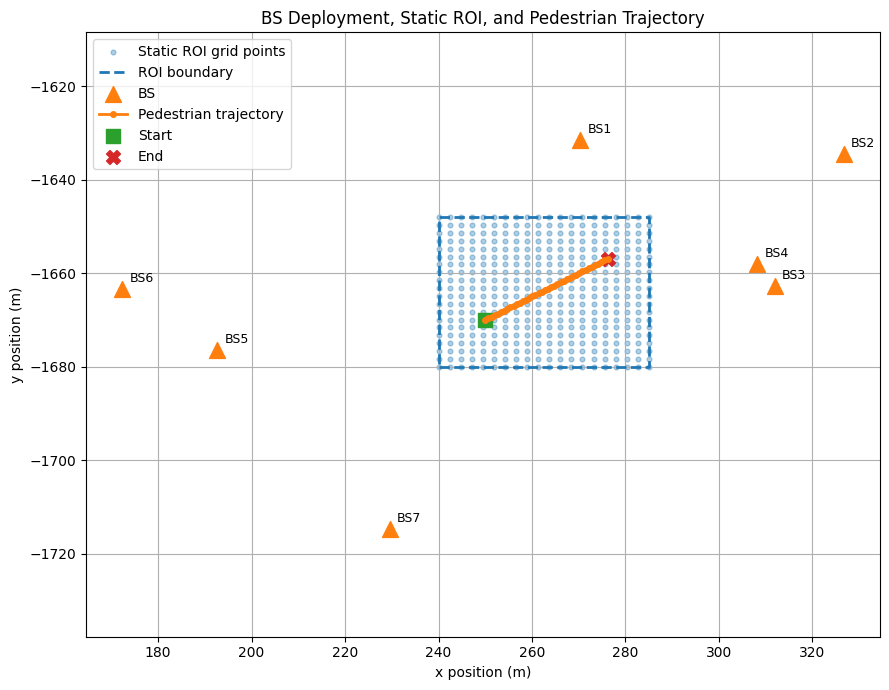

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

# ============================================================
# 1. 기본 설정: BS 위치, ROI, 보행자 경로
# ============================================================

BS_Z = 50.0
TARGET_Z = 20.0

all_bs = np.array([
    [270.370, -1631.474, BS_Z],
    [326.736, -1634.541, BS_Z],
    [311.936, -1662.765, BS_Z],
    [308.222, -1657.997, BS_Z],
    [192.678, -1676.419, BS_Z],
    [172.344, -1663.427, BS_Z],
    [229.612, -1714.744, BS_Z],
])

# ROI Static 400 영역
x_range = np.linspace(240.0, 285.0, 20)
y_range = np.linspace(-1680.0, -1648.0, 20)

X, Y = np.meshgrid(x_range, y_range)

# Dynamic tracking trajectory
walking_speed = 1.5
duration = 20
dt = 0.5
num_steps = int(duration / dt)

start_pos = np.array([250.0, -1670.0, TARGET_Z])
direction = np.array([1.0, 0.5, 0.0])
direction = direction / np.linalg.norm(direction)

pos = start_pos.copy().astype(float)
vel = direction * walking_speed

X_MIN, X_MAX = 180.0, 320.0
Y_MIN, Y_MAX = -1710.0, -1635.0

true_trajectory = []

for step in range(num_steps):
    if pos[0] > X_MAX:
        vel[0] = -abs(vel[0])
    if pos[0] < X_MIN:
        vel[0] = abs(vel[0])
    if pos[1] > Y_MAX:
        vel[1] = -abs(vel[1])
    if pos[1] < Y_MIN:
        vel[1] = abs(vel[1])

    true_trajectory.append(pos.copy())
    pos = pos + vel * dt

true_trajectory = np.array(true_trajectory)

# ============================================================
# 2. 시각화
# ============================================================

plt.figure(figsize=(9, 7))

# Static ROI grid points
plt.scatter(
    X.flatten(),
    Y.flatten(),
    s=12,
    alpha=0.35,
    label="Static ROI grid points"
)

# ROI boundary
plt.plot(
    [x_range[0], x_range[-1], x_range[-1], x_range[0], x_range[0]],
    [y_range[0], y_range[0], y_range[-1], y_range[-1], y_range[0]],
    linestyle="--",
    linewidth=2,
    label="ROI boundary"
)

# BS positions
plt.scatter(
    all_bs[:, 0],
    all_bs[:, 1],
    marker="^",
    s=130,
    label="BS"
)

# BS labels
for i, bs in enumerate(all_bs):
    plt.text(
        bs[0] + 1.5,
        bs[1] + 1.5,
        f"BS{i+1}",
        fontsize=9
    )

# Pedestrian trajectory
plt.plot(
    true_trajectory[:, 0],
    true_trajectory[:, 1],
    marker="o",
    markersize=4,
    linewidth=2,
    label="Pedestrian trajectory"
)

# Start / End
plt.scatter(
    true_trajectory[0, 0],
    true_trajectory[0, 1],
    marker="s",
    s=90,
    label="Start"
)

plt.scatter(
    true_trajectory[-1, 0],
    true_trajectory[-1, 1],
    marker="X",
    s=100,
    label="End"
)

plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.title("BS Deployment, Static ROI, and Pedestrian Trajectory")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

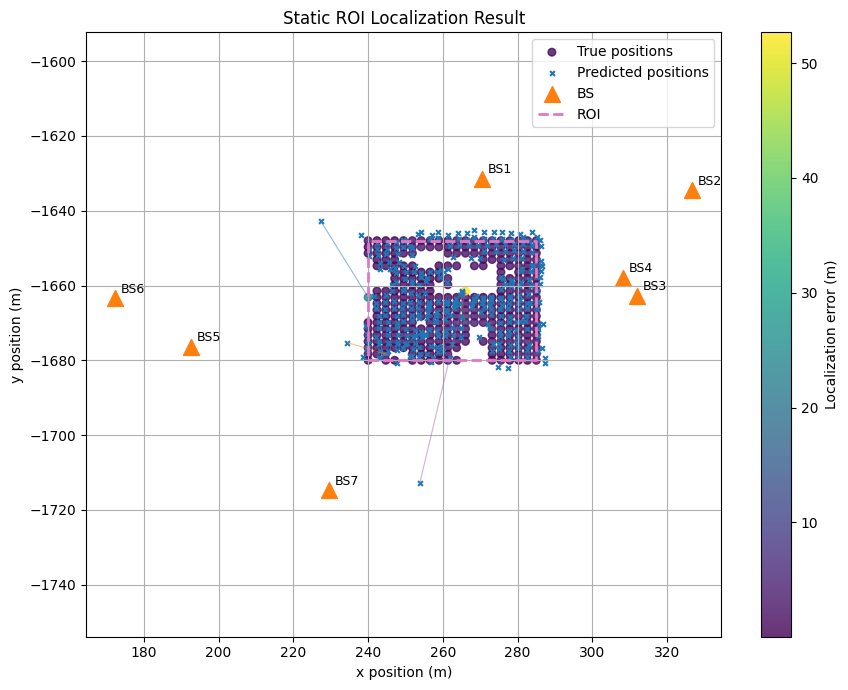

In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Static ROI 결과 불러오기
# ============================================================

with open("/home/yerim/isac_static_roi_400_result.pkl", "rb") as f:
    data = pickle.load(f)

dataset = data["dataset"]
all_bs = np.array(data["all_bs"])
x_range = np.array(data["x_range"])
y_range = np.array(data["y_range"])

true_pts = []
pred_pts = []
errors = []

for d in dataset:
    if d["pred_position"] is not None:
        true_pts.append(d["true_position"])
        pred_pts.append(d["pred_position"])
        errors.append(d["error"])

true_pts = np.array(true_pts)
pred_pts = np.array(pred_pts)
errors = np.array(errors)

# ============================================================
# True vs Pred 시각화
# ============================================================

plt.figure(figsize=(9, 7))

# Error 크기별 true point
sc = plt.scatter(
    true_pts[:, 0],
    true_pts[:, 1],
    c=errors,
    s=30,
    alpha=0.8,
    label="True positions"
)

plt.colorbar(sc, label="Localization error (m)")

# Predicted positions
plt.scatter(
    pred_pts[:, 0],
    pred_pts[:, 1],
    s=12,
    marker="x",
    label="Predicted positions"
)

# True-pred 연결선
for t, p, e in zip(true_pts, pred_pts, errors):
    if e > 5:
        plt.plot(
            [t[0], p[0]],
            [t[1], p[1]],
            linewidth=0.8,
            alpha=0.5
        )

# BS positions
plt.scatter(
    all_bs[:, 0],
    all_bs[:, 1],
    marker="^",
    s=130,
    label="BS"
)

for i, bs in enumerate(all_bs):
    plt.text(bs[0] + 1.5, bs[1] + 1.5, f"BS{i+1}", fontsize=9)

# ROI boundary
plt.plot(
    [x_range[0], x_range[-1], x_range[-1], x_range[0], x_range[0]],
    [y_range[0], y_range[0], y_range[-1], y_range[-1], y_range[0]],
    linestyle="--",
    linewidth=2,
    label="ROI"
)

plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.title("Static ROI Localization Result")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

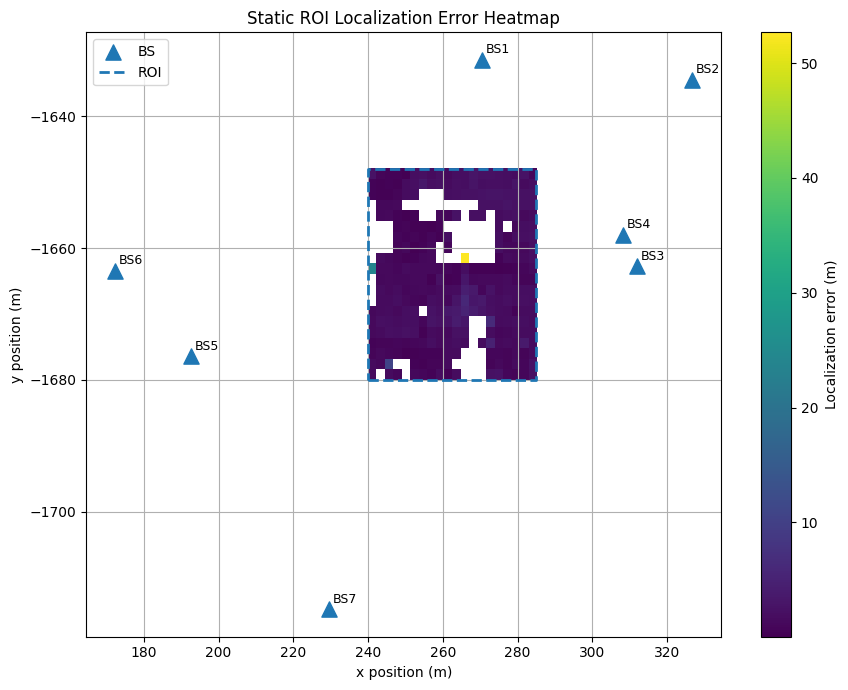

In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Static ROI 결과 불러오기
# ============================================================
with open("/home/yerim/isac_static_roi_400_result.pkl", "rb") as f:
    data = pickle.load(f)

dataset = data["dataset"]
all_bs = np.array(data["all_bs"])
x_range = np.array(data["x_range"])
y_range = np.array(data["y_range"])

# ============================================================
# 2. Error grid 만들기
# ============================================================
error_grid = np.full((len(y_range), len(x_range)), np.nan)
valid_bs_grid = np.full((len(y_range), len(x_range)), np.nan)

for d in dataset:
    x, y = d["true_position"]
    error = d["error"]
    n_bs = d["n_valid_bs"]

    ix = np.argmin(np.abs(x_range - x))
    iy = np.argmin(np.abs(y_range - y))

    if error is not None:
        error_grid[iy, ix] = error

    valid_bs_grid[iy, ix] = n_bs

# ============================================================
# 3. Error Heatmap
# ============================================================
plt.figure(figsize=(9, 7))

plt.imshow(
    error_grid,
    extent=[x_range[0], x_range[-1], y_range[0], y_range[-1]],
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Localization error (m)")

# BS 위치 표시
plt.scatter(
    all_bs[:, 0],
    all_bs[:, 1],
    marker="^",
    s=120,
    label="BS"
)

for i, bs in enumerate(all_bs):
    plt.text(bs[0] + 1.0, bs[1] + 1.0, f"BS{i+1}", fontsize=9)

# ROI 경계선
plt.plot(
    [x_range[0], x_range[-1], x_range[-1], x_range[0], x_range[0]],
    [y_range[0], y_range[0], y_range[-1], y_range[-1], y_range[0]],
    linestyle="--",
    linewidth=2,
    label="ROI"
)

plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.title("Static ROI Localization Error Heatmap")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [2]:
# ============================================================
# Ground-Level UE-Free Human Tracking
# Digital Twin Prior Channel Difference + Curved Trajectory
# ============================================================

import mitsuba as mi
mi.set_variant("llvm_ad_mono_polarized")

import numpy as np
import time
import pickle
from scipy.optimize import minimize

from sionna.rt import (
    load_scene, Transmitter, Receiver, PlanarArray,
    PathSolver, RadioMaterial, SceneObject
)

# ============================================================
# Reproducibility
# ============================================================

np.random.seed(42)

c = 3e8
CARRIER_FREQ = 3.5e9  # Sionna RT 확인 주파수

# ============================================================
# STEP 1. Scene Load
# ============================================================

scene = load_scene("/home/yerim/Downloads/material_NEW_seongbuk(1).xml")

scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V"
)

scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V"
)

print(f"📡 Carrier frequency: {CARRIER_FREQ/1e9:.2f} GHz")

# ============================================================
# STEP 2. BS Deployment
# ============================================================

BS_Z = 50.0
TARGET_Z = 20.0

all_bs = [
    [270.370, -1631.474, BS_Z],
    [326.736, -1634.541, BS_Z],
    [311.936, -1662.765, BS_Z],
    [308.222, -1657.997, BS_Z],
    [192.678, -1676.419, BS_Z],
    [172.344, -1663.427, BS_Z],
    [229.612, -1714.744, BS_Z],
]

rx_offsets = [[1.0, 0.0]] * len(all_bs)

for i, (bp, offset) in enumerate(zip(all_bs, rx_offsets)):
    scene.add(
        Transmitter(
            f"tx{i+1}",
            position=bp
        )
    )

    scene.add(
        Receiver(
            f"rx{i+1}",
            position=[
                bp[0] + offset[0],
                bp[1] + offset[1],
                bp[2]
            ]
        )
    )

print(f"✅ BS {len(all_bs)}개 배치")

# ============================================================
# STEP 3. Human Material
# ============================================================

human_mat = RadioMaterial(
    "human",
    relative_permittivity=40.0,
    conductivity=0.8,
    scattering_coefficient=0.5,
    thickness=0.1
)

scene.add(human_mat)
solver = PathSolver()

# ============================================================
# STEP 4. H_prior Calculation
# ============================================================

print("\nH_prior 계산 중...")

try:
    scene.edit(remove="target")
except:
    pass

paths_prior = solver(
    scene,
    synthetic_array=True,
    max_depth=3,
    los=True,
    specular_reflection=True,
    diffuse_reflection=False,
    seed=42
)

a_prior, tau_prior = paths_prior.cir(
    normalize_delays=False,
    out_type="numpy"
)

prior_dists_all = {}

for bs_idx in range(len(all_bs)):
    dists = set()

    for i in range(a_prior.shape[4]):
        t = float(tau_prior[bs_idx, bs_idx, i])

        if t > 0:
            dists.add(t * c / 2)

    prior_dists_all[bs_idx] = dists

print("✅ H_prior 완료")
print(f"✅ H_prior shape = {a_prior.shape}")

# ============================================================
# STEP 5. Curved Pedestrian Trajectory
# ============================================================

walking_speed = 1.5   # m/s
duration = 30         # 30초로 확장
dt = 0.5
num_steps = int(duration / dt)

# ROI 범위
X_MIN, X_MAX = 240.0, 285.0
Y_MIN, Y_MAX = -1680.0, -1648.0

# S자 경로 설정
x_start = 245.0
x_end = 280.0

y_center = -1664.0
y_amp = 10.0

true_trajectory = []
true_velocities = []

positions = []

for step in range(num_steps):
    s = step / (num_steps - 1)  # 0~1 정규화 시간

    # x 방향으로 이동
    x = x_start + (x_end - x_start) * s

    # y 방향으로 S자 움직임
    y = y_center + y_amp * np.sin(2 * np.pi * 1.5 * s)

    # ROI 내부로 제한
    x = np.clip(x, X_MIN, X_MAX)
    y = np.clip(y, Y_MIN, Y_MAX)

    positions.append([x, y, TARGET_Z])

positions = np.array(positions)

# velocity 계산 및 walking_speed로 정규화
for step in range(num_steps):

    if step == 0:
        vel = (positions[1] - positions[0]) / dt

    elif step == num_steps - 1:
        vel = (positions[-1] - positions[-2]) / dt

    else:
        vel = (positions[step + 1] - positions[step - 1]) / (2 * dt)

    vel_xy = vel[:2]
    norm_v = np.linalg.norm(vel_xy)

    if norm_v > 1e-9:
        vel_xy = vel_xy / norm_v * walking_speed
    else:
        vel_xy = np.array([0.0, 0.0])

    true_trajectory.append(positions[step].tolist())
    true_velocities.append([vel_xy[0], vel_xy[1], 0.0])

print(f"✅ 곡선형 보행자 경로 생성 완료: {num_steps} steps, {duration}초")

# ============================================================
# STEP 6. Add Target Function
# ============================================================

def add_target(x, y, vx=0.0, vy=0.0, z=TARGET_Z):
    """
    Ground-level pedestrian target.
    z는 지면 높이.
    cuboid 중심을 z+0.85에 둬서 발이 지면에 닿도록 설정.
    """

    try:
        scene.edit(remove="target")
    except:
        pass

    box_mesh = mi.load_dict({
        "type": "cube",
        "to_world": (
            mi.ScalarTransform4f.translate([
                float(x),
                float(y),
                float(z + 0.85)
            ])
            @
            mi.ScalarTransform4f.scale([
                0.3,
                0.3,
                0.85
            ])
        )
    })

    target_obj = SceneObject(
        mi_mesh=box_mesh,
        name="target",
        radio_material=human_mat
    )

    scene.edit(add=target_obj)

    # Doppler 반영을 위한 velocity 설정
    scene.get("target").velocity = [
        float(vx),
        float(vy),
        0.0
    ]

# ============================================================
# STEP 7. Multilateration Initial Points
# ============================================================

x_init = np.arange(235.0, 291.0, 10.0)
y_init = np.arange(-1685.0, -1643.0, 10.0)

init_points = [
    [x, y]
    for x in x_init
    for y in y_init
]

print(f"✅ Multilateration 초기값: {len(init_points)}개")

# ============================================================
# STEP 8. Parameters
# ============================================================

MIN_BS = 3
CLUTTER_THRESH = 1.0
MAX_RANGE_HORIZ = 120.0
AMP_THRESH = 1e-10

MOTION_WEIGHT = 0.2   # 약한 시간 연속성 제약
JUMP_THRESHOLD = 20.0 # 너무 큰 발산만 억제

print(f"✅ MIN_BS = {MIN_BS}")
print(f"✅ CLUTTER_THRESH = {CLUTTER_THRESH} m")
print(f"✅ MAX_RANGE_HORIZ = {MAX_RANGE_HORIZ} m")
print(f"✅ MOTION_WEIGHT = {MOTION_WEIGHT}")

# ============================================================
# STEP 9. Real-Time Tracking
# ============================================================

trajectory_results = []
t_start = time.time()

print("\n곡선형 보행자 실시간 추적 시작...")
print("=" * 70)

for step in range(num_steps):

    pos = true_trajectory[step]
    vel_step = true_velocities[step]

    # --------------------------------------------------------
    # 1) Target 배치
    # --------------------------------------------------------

    add_target(
        pos[0],
        pos[1],
        vx=vel_step[0],
        vy=vel_step[1]
    )

    # --------------------------------------------------------
    # 2) H_meas 계산
    # --------------------------------------------------------

    paths_meas = solver(
        scene,
        synthetic_array=True,
        max_depth=3,
        los=True,
        specular_reflection=True,
        diffuse_reflection=True,
        seed=42
    )

    a_meas, tau_meas = paths_meas.cir(
        normalize_delays=False,
        out_type="numpy"
    )

    doppler = np.array(paths_meas.doppler)

    # --------------------------------------------------------
    # 3) H_meas - H_prior 차분 기반 신규 path 추출
    # --------------------------------------------------------

    ranges = []
    dopplers = []

    for bs_idx in range(len(all_bs)):

        bp = all_bs[bs_idx]
        dz_bs = abs(bp[2] - TARGET_Z)
        prior_dists = prior_dists_all[bs_idx]

        new_paths = []

        for i in range(a_meas.shape[4]):

            t = float(tau_meas[bs_idx, bs_idx, i])

            if t <= 0:
                continue

            dist = t * c / 2

            a_m = float(
                np.abs(a_meas)[
                    bs_idx,
                    0,
                    bs_idx,
                    0,
                    i,
                    0
                ]
            )

            if a_m <= AMP_THRESH:
                continue

            # 핵심 차분:
            # H_prior에 있던 경로면 버리고,
            # H_prior에 없던 경로면 사람 때문에 생긴 new path로 판단
            is_new = not any(
                abs(dist - pd) < CLUTTER_THRESH
                for pd in prior_dists
            )

            if is_new:
                try:
                    f_doppler = float(doppler[bs_idx, bs_idx, i])
                except:
                    f_doppler = 0.0

                new_paths.append(
                    (dist, a_m, f_doppler)
                )

        # ----------------------------------------------------
        # 4) Candidate path 선택
        # ----------------------------------------------------

        if new_paths:

            # Dynamic tracking에서는 짧고 강한 path를 우선 선택
            best = min(
                new_paths,
                key=lambda v: v[0] / (v[1] + 1e-9)
            )

            if best[0] >= dz_bs:

                r_horiz = np.sqrt(best[0]**2 - dz_bs**2)

                if r_horiz > MAX_RANGE_HORIZ:
                    continue

                ranges.append(
                    (bs_idx, r_horiz)
                )

                dopplers.append(best[2])

    # --------------------------------------------------------
    # 5) Multilateration
    # --------------------------------------------------------

    pred_pos = None
    error = None
    best_cost = None

    if len(ranges) >= MIN_BS:

        bs_2d = np.array([
            [bp[0], bp[1]]
            for bp in all_bs
        ])

        prev_results = [
            r for r in trajectory_results
            if r["pred_pos"] is not None
        ]

        prev_pred = None

        if prev_results:
            prev_pred = np.array(
                prev_results[-1]["pred_pos"]
            )

        def cost(p):

            range_error = sum(
                (
                    np.sqrt(
                        (p[0] - bs_2d[idx][0])**2 +
                        (p[1] - bs_2d[idx][1])**2
                    ) - r
                )**2
                for idx, r in ranges
            )

            motion_penalty = 0.0

            if prev_pred is not None:
                motion_penalty = (
                    MOTION_WEIGHT *
                    np.linalg.norm(p - prev_pred)**2
                )

            return range_error + motion_penalty

        # 이전 위치 주변 초기값 + 전체 grid 초기값
        if prev_pred is not None:

            local_inits = [
                prev_pred + np.random.randn(2) * 3
                for _ in range(30)
            ]

            local_inits.append(prev_pred.tolist())

            search_points = local_inits + init_points

        else:
            search_points = init_points

        best_result = None
        best_cost_val = float("inf")

        for x0 in search_points:

            result = minimize(
                cost,
                x0,
                method="Nelder-Mead",
                options={
                    "xatol": 0.01,
                    "fatol": 0.01,
                    "maxiter": 10000
                }
            )

            if result.fun < best_cost_val:
                best_cost_val = result.fun
                best_result = result

        pred_pos = best_result.x.tolist()
        best_cost = float(best_cost_val)

        # 너무 큰 순간 jump만 억제
        if prev_pred is not None:
            jump = np.linalg.norm(
                np.array(pred_pos) - prev_pred
            )

            if jump > JUMP_THRESHOLD:
                pred_pos = prev_pred.tolist()
                print(f"  ⚠️ Jump {jump:.1f}m 감지 → 이전 위치 유지")

        error = float(
            np.sqrt(
                (pred_pos[0] - pos[0])**2 +
                (pred_pos[1] - pos[1])**2
            )
        )

    # --------------------------------------------------------
    # 6) Doppler summary
    # --------------------------------------------------------

    if dopplers:

        speed_per_bs = [
            abs(d) * c / (2 * CARRIER_FREQ)
            for d in dopplers
        ]

        estimated_speed = float(
            np.median(speed_per_bs)
        )

        avg_abs_doppler = float(
            np.mean([abs(d) for d in dopplers])
        )

    else:
        estimated_speed = 0.0
        avg_abs_doppler = 0.0

    trajectory_results.append({
        "step": step,
        "time": step * dt,
        "true_pos": pos[:2],
        "true_velocity": vel_step[:2],
        "pred_pos": pred_pos,
        "error": error,
        "n_bs": len(ranges),
        "ranges": [
            (int(idx), float(r))
            for idx, r in ranges
        ],
        "avg_abs_doppler": avg_abs_doppler,
        "est_speed": estimated_speed,
        "best_cost": best_cost
    })

    # --------------------------------------------------------
    # 7) Print status
    # --------------------------------------------------------

    if pred_pos is not None:
        status = (
            f"추정: ({pred_pos[0]:.1f}, {pred_pos[1]:.1f}) | "
            f"오차: {error:.2f}m"
        )
    else:
        status = "추정 불가 (유효 BS 부족)"

    print(
        f"t={step*dt:4.1f}s | "
        f"실제: ({pos[0]:.1f}, {pos[1]:.1f}) | "
        f"{status} | "
        f"BS={len(ranges)} | "
        f"|f_d|={avg_abs_doppler:.1f}Hz | "
        f"v_est={estimated_speed:.2f}m/s"
    )

# ============================================================
# STEP 10. Statistics
# ============================================================

elapsed = time.time() - t_start

errors = [
    r["error"]
    for r in trajectory_results
    if r["error"] is not None
]

speeds = [
    r["est_speed"]
    for r in trajectory_results
    if r["n_bs"] >= MIN_BS
]

errors_np = np.array(errors)

print("\n" + "=" * 70)
print("곡선형 보행자 실시간 추적 결과")
print("=" * 70)

print(f"추적 시간:        {duration}초")
print(f"총 step:          {num_steps}")
print(f"유효 샘플:        {len(errors_np)}/{num_steps}")

if len(errors_np) > 0:
    print(f"평균 오차:        {np.mean(errors_np):.2f} m")
    print(f"중앙값 오차:      {np.median(errors_np):.2f} m")
    print(f"RMSE:             {np.sqrt(np.mean(errors_np**2)):.2f} m")
    print(f"P90 오차:         {np.percentile(errors_np, 90):.2f} m")
    print(f"최대 오차:        {np.max(errors_np):.2f} m")

    print(f"\n< 1m 비율:        {np.mean(errors_np < 1.0)*100:.1f}%")
    print(f"< 2m 비율:        {np.mean(errors_np < 2.0)*100:.1f}%")
    print(f"< 5m 비율:        {np.mean(errors_np < 5.0)*100:.1f}%")
    print(f"< 10m 비율:       {np.mean(errors_np < 10.0)*100:.1f}%")

if len(speeds) > 0:
    print(f"\n실제 속도:        {walking_speed:.2f} m/s")
    print(f"추정 속도 median: {np.median(speeds):.2f} m/s")
    print(f"추정 속도 mean:   {np.mean(speeds):.2f} m/s")
    print(f"추정 속도 범위:   {np.min(speeds):.2f} ~ {np.max(speeds):.2f} m/s")

print(f"\n총 소요 시간:     {elapsed:.1f}초")
print(f"step당 시간:      {elapsed/num_steps:.2f}초")

# ============================================================
# STEP 11. Save
# ============================================================

with open("/home/yerim/isac_tracking_curved_result.pkl", "wb") as f:
    pickle.dump({
        "true_trajectory": true_trajectory,
        "true_velocities": true_velocities,
        "trajectory_results": trajectory_results,
        "all_bs": all_bs,
        "walking_speed": walking_speed,
        "duration": duration,
        "dt": dt,
        "BS_Z": BS_Z,
        "TARGET_Z": TARGET_Z,
        "carrier_freq": CARRIER_FREQ,
        "MIN_BS": MIN_BS,
        "CLUTTER_THRESH": CLUTTER_THRESH,
        "MAX_RANGE_HORIZ": MAX_RANGE_HORIZ,
        "MOTION_WEIGHT": MOTION_WEIGHT,
        "JUMP_THRESHOLD": JUMP_THRESHOLD,
        "trajectory_type": "S-shaped curved trajectory"
    }, f)

print("\n✅ 저장 완료: /home/yerim/isac_tracking_curved_result.pkl")

📡 Carrier frequency: 3.50 GHz
✅ BS 7개 배치

H_prior 계산 중...
✅ H_prior 완료
✅ H_prior shape = (7, 1, 7, 1, 20, 1)
✅ 곡선형 보행자 경로 생성 완료: 60 steps, 30초
✅ Multilateration 초기값: 30개
✅ MIN_BS = 3
✅ CLUTTER_THRESH = 1.0 m
✅ MAX_RANGE_HORIZ = 120.0 m
✅ MOTION_WEIGHT = 0.2

곡선형 보행자 실시간 추적 시작...
t= 0.0s | 실제: (245.0, -1664.0) | 추정: (245.4, -1665.2) | 오차: 1.32m | BS=3 | |f_d|=18.8Hz | v_est=0.59m/s
t= 0.5s | 실제: (245.6, -1662.4) | 추정: (245.4, -1663.7) | 오차: 1.35m | BS=4 | |f_d|=17.1Hz | v_est=0.57m/s
t= 1.0s | 실제: (246.2, -1660.9) | 추정 불가 (유효 BS 부족) | BS=2 | |f_d|=24.9Hz | v_est=1.07m/s
t= 1.5s | 실제: (246.8, -1659.4) | 추정 불가 (유효 BS 부족) | BS=2 | |f_d|=21.3Hz | v_est=0.91m/s
t= 2.0s | 실제: (247.4, -1658.0) | 추정: (247.1, -1655.4) | 오차: 2.66m | BS=4 | |f_d|=22.7Hz | v_est=1.03m/s
t= 2.5s | 실제: (248.0, -1656.8) | 추정: (248.2, -1656.6) | 오차: 0.34m | BS=3 | |f_d|=23.3Hz | v_est=1.13m/s
t= 3.0s | 실제: (248.6, -1655.8) | 추정: (249.0, -1656.5) | 오차: 0.77m | BS=3 | |f_d|=24.3Hz | v_est=1.11m/s
t= 3.5s | 실제: (249.2, -1

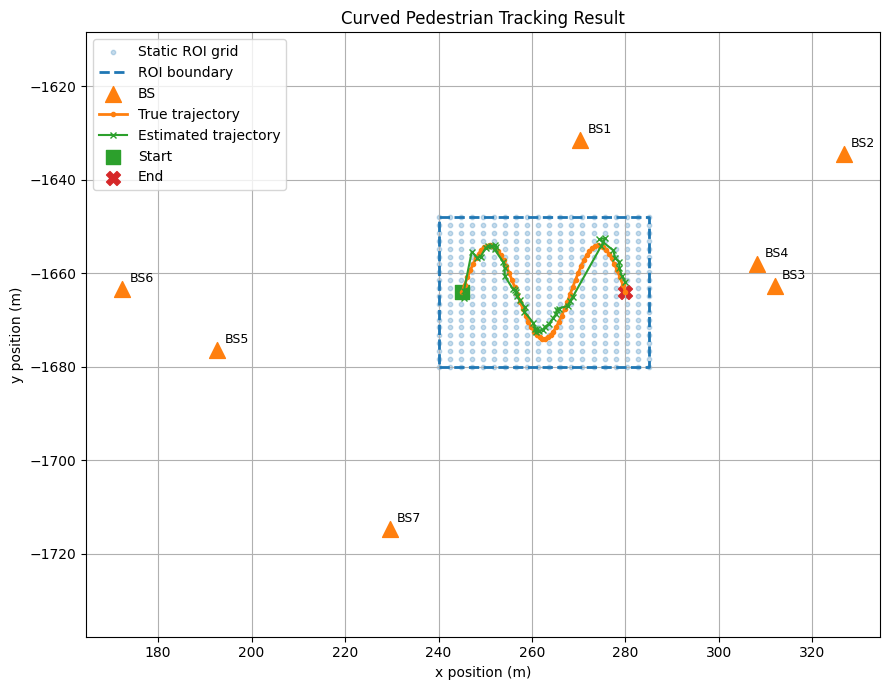

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("/home/yerim/isac_tracking_curved_result.pkl", "rb") as f:
    data = pickle.load(f)

true_traj = np.array(data["true_trajectory"])
results = data["trajectory_results"]
all_bs = np.array(data["all_bs"])

pred_pts = []
true_valid = []
errors = []

for r in results:
    if r["pred_pos"] is not None:
        pred_pts.append(r["pred_pos"])
        true_valid.append(r["true_pos"])
        errors.append(r["error"])

pred_pts = np.array(pred_pts)
true_valid = np.array(true_valid)
errors = np.array(errors)

# ROI
x_range = np.linspace(240.0, 285.0, 20)
y_range = np.linspace(-1680.0, -1648.0, 20)
X, Y = np.meshgrid(x_range, y_range)

plt.figure(figsize=(9, 7))

# Static ROI grid
plt.scatter(
    X.flatten(),
    Y.flatten(),
    s=10,
    alpha=0.25,
    label="Static ROI grid"
)

# ROI boundary
plt.plot(
    [x_range[0], x_range[-1], x_range[-1], x_range[0], x_range[0]],
    [y_range[0], y_range[0], y_range[-1], y_range[-1], y_range[0]],
    linestyle="--",
    linewidth=2,
    label="ROI boundary"
)

# BS
plt.scatter(
    all_bs[:, 0],
    all_bs[:, 1],
    marker="^",
    s=130,
    label="BS"
)

for i, bs in enumerate(all_bs):
    plt.text(bs[0] + 1.5, bs[1] + 1.5, f"BS{i+1}", fontsize=9)

# True trajectory
plt.plot(
    true_traj[:, 0],
    true_traj[:, 1],
    marker="o",
    markersize=3,
    linewidth=2,
    label="True trajectory"
)

# Predicted trajectory
if len(pred_pts) > 0:
    plt.plot(
        pred_pts[:, 0],
        pred_pts[:, 1],
        marker="x",
        markersize=4,
        linewidth=1.5,
        label="Estimated trajectory"
    )

# Start / End
plt.scatter(
    true_traj[0, 0],
    true_traj[0, 1],
    marker="s",
    s=90,
    label="Start"
)

plt.scatter(
    true_traj[-1, 0],
    true_traj[-1, 1],
    marker="X",
    s=100,
    label="End"
)

plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.title("Curved Pedestrian Tracking Result")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# Ground-Level UE-Free Human Tracking
# Wide ROI-Covering Curved Trajectory Version
# Digital Twin Prior Channel Difference + Multilateration
# ============================================================

import mitsuba as mi
mi.set_variant("llvm_ad_mono_polarized")

import numpy as np
import time
import pickle
from scipy.optimize import minimize

from sionna.rt import (
    load_scene, Transmitter, Receiver, PlanarArray,
    PathSolver, RadioMaterial, SceneObject
)

# ============================================================
# Reproducibility
# ============================================================
np.random.seed(42)

c = 3e8
CARRIER_FREQ = 3.5e9

# ============================================================
# STEP 1. Scene Load
# ============================================================
scene = load_scene("/home/yerim/Downloads/material_NEW_seongbuk(1).xml")

scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V"
)

scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V"
)

print(f"📡 Carrier frequency: {CARRIER_FREQ/1e9:.2f} GHz")

# ============================================================
# STEP 2. BS Deployment
# ============================================================
BS_Z = 50.0
TARGET_Z = 20.0

all_bs = [
    [270.370, -1631.474, BS_Z],
    [326.736, -1634.541, BS_Z],
    [311.936, -1662.765, BS_Z],
    [308.222, -1657.997, BS_Z],
    [192.678, -1676.419, BS_Z],
    [172.344, -1663.427, BS_Z],
    [229.612, -1714.744, BS_Z],
]

rx_offsets = [[1.0, 0.0]] * len(all_bs)

for i, (bp, offset) in enumerate(zip(all_bs, rx_offsets)):
    scene.add(
        Transmitter(
            f"tx{i+1}",
            position=bp
        )
    )

    scene.add(
        Receiver(
            f"rx{i+1}",
            position=[
                bp[0] + offset[0],
                bp[1] + offset[1],
                bp[2]
            ]
        )
    )

print(f"✅ BS {len(all_bs)}개 배치")

# ============================================================
# STEP 3. Human Material
# ============================================================
human_mat = RadioMaterial(
    "human",
    relative_permittivity=40.0,
    conductivity=0.8,
    scattering_coefficient=0.5,
    thickness=0.1
)

scene.add(human_mat)
solver = PathSolver()

# ============================================================
# STEP 4. H_prior Calculation
# ============================================================
print("\nH_prior 계산 중...")

try:
    scene.edit(remove="target")
except:
    pass

paths_prior = solver(
    scene,
    synthetic_array=True,
    max_depth=3,
    los=True,
    specular_reflection=True,
    diffuse_reflection=False,
    seed=42
)

a_prior, tau_prior = paths_prior.cir(
    normalize_delays=False,
    out_type="numpy"
)

prior_dists_all = {}

for bs_idx in range(len(all_bs)):
    dists = set()

    for i in range(a_prior.shape[4]):
        t = float(tau_prior[bs_idx, bs_idx, i])

        if t > 0:
            dists.add(t * c / 2)

    prior_dists_all[bs_idx] = dists

print("✅ H_prior 완료")
print(f"✅ H_prior shape = {a_prior.shape}")

# ============================================================
# STEP 5. Wide Curved Pedestrian Trajectory
# ============================================================
# 기지국 범위 안쪽을 최대한 넓게 쓰는 S자 경로
# 위치는 arclength 기준으로 재샘플링해서 실제 속도 1.5 m/s에 맞춤

walking_speed = 1.5
dt = 0.5

# 넓은 tracking ROI
# 기존 ROI보다 넓게 설정
X_MIN, X_MAX = 235.0, 310.0
Y_MIN, Y_MAX = -1710.0, -1635.0

# 경로가 ROI를 꽉 차게 쓰도록 설정
x_start = 240.0
x_end = 305.0
y_center = (Y_MIN + Y_MAX) / 2.0
y_amp = 32.0

# S자 반복 횟수
# 1.25~1.5 사이 추천. 너무 크면 경로 길이가 길어져서 실행 시간이 늘어남.
num_waves = 1.25

# dense curve 생성
dense_N = 2000
s_dense = np.linspace(0.0, 1.0, dense_N)

x_dense = x_start + (x_end - x_start) * s_dense
y_dense = y_center + y_amp * np.sin(2 * np.pi * num_waves * s_dense)

x_dense = np.clip(x_dense, X_MIN, X_MAX)
y_dense = np.clip(y_dense, Y_MIN, Y_MAX)

dense_positions = np.stack(
    [x_dense, y_dense, np.full_like(x_dense, TARGET_Z)],
    axis=1
)

# arclength 계산
diffs = np.diff(dense_positions[:, :2], axis=0)
seg_lengths = np.linalg.norm(diffs, axis=1)
cum_len = np.concatenate([[0.0], np.cumsum(seg_lengths)])
total_len = cum_len[-1]

# 실제 walking_speed와 dt에 맞춰 샘플링
step_dist = walking_speed * dt
sample_dists = np.arange(0.0, total_len, step_dist)

true_trajectory = []
true_velocities = []

# arclength 기준 위치 보간
x_sample = np.interp(sample_dists, cum_len, dense_positions[:, 0])
y_sample = np.interp(sample_dists, cum_len, dense_positions[:, 1])

positions = np.stack(
    [x_sample, y_sample, np.full_like(x_sample, TARGET_Z)],
    axis=1
)

num_steps = len(positions)
duration = (num_steps - 1) * dt

# velocity 계산
for step in range(num_steps):

    if step == 0:
        vel = (positions[1] - positions[0]) / dt

    elif step == num_steps - 1:
        vel = (positions[-1] - positions[-2]) / dt

    else:
        vel = (positions[step + 1] - positions[step - 1]) / (2 * dt)

    vel_xy = vel[:2]
    norm_v = np.linalg.norm(vel_xy)

    if norm_v > 1e-9:
        vel_xy = vel_xy / norm_v * walking_speed
    else:
        vel_xy = np.array([0.0, 0.0])

    true_trajectory.append(positions[step].tolist())
    true_velocities.append([vel_xy[0], vel_xy[1], 0.0])

print("✅ 넓은 곡선형 보행자 경로 생성 완료")
print(f"   총 경로 길이: {total_len:.1f} m")
print(f"   추적 시간:   {duration:.1f} s")
print(f"   총 step:     {num_steps}")
print(f"   ROI: x={X_MIN}~{X_MAX}, y={Y_MIN}~{Y_MAX}")

# ============================================================
# STEP 6. Add Target Function
# ============================================================
def add_target(x, y, vx=0.0, vy=0.0, z=TARGET_Z):
    """
    Ground-level pedestrian target.
    z는 지면 높이.
    cuboid 중심을 z+0.85에 둬서 발이 지면에 닿도록 설정.
    """

    try:
        scene.edit(remove="target")
    except:
        pass

    box_mesh = mi.load_dict({
        "type": "cube",
        "to_world": (
            mi.ScalarTransform4f.translate([
                float(x),
                float(y),
                float(z + 0.85)
            ])
            @
            mi.ScalarTransform4f.scale([
                0.3,
                0.3,
                0.85
            ])
        )
    })

    target_obj = SceneObject(
        mi_mesh=box_mesh,
        name="target",
        radio_material=human_mat
    )

    scene.edit(add=target_obj)

    # Doppler 반영
    scene.get("target").velocity = [
        float(vx),
        float(vy),
        0.0
    ]

# ============================================================
# STEP 7. Multilateration Initial Points
# ============================================================
# 넓어진 ROI에 맞춰 초기값도 넓게 설정

x_init = np.arange(X_MIN, X_MAX + 1, 10.0)
y_init = np.arange(Y_MIN, Y_MAX + 1, 10.0)

init_points = [
    [x, y]
    for x in x_init
    for y in y_init
]

print(f"✅ Multilateration 초기값: {len(init_points)}개")

# ============================================================
# STEP 8. Parameters
# ============================================================
MIN_BS = 3
CLUTTER_THRESH = 1.0
MAX_RANGE_HORIZ = 140.0
AMP_THRESH = 1e-10

MOTION_WEIGHT = 0.2
JUMP_THRESHOLD = 25.0

print(f"✅ MIN_BS = {MIN_BS}")
print(f"✅ CLUTTER_THRESH = {CLUTTER_THRESH} m")
print(f"✅ MAX_RANGE_HORIZ = {MAX_RANGE_HORIZ} m")
print(f"✅ MOTION_WEIGHT = {MOTION_WEIGHT}")

# ============================================================
# STEP 9. Real-Time Tracking
# ============================================================
trajectory_results = []
t_start = time.time()

print("\n넓은 곡선형 보행자 실시간 추적 시작...")
print("=" * 70)

for step in range(num_steps):

    pos = true_trajectory[step]
    vel_step = true_velocities[step]

    # --------------------------------------------------------
    # 1) Target 배치
    # --------------------------------------------------------
    add_target(
        pos[0],
        pos[1],
        vx=vel_step[0],
        vy=vel_step[1]
    )

    # --------------------------------------------------------
    # 2) H_meas 계산
    # --------------------------------------------------------
    paths_meas = solver(
        scene,
        synthetic_array=True,
        max_depth=3,
        los=True,
        specular_reflection=True,
        diffuse_reflection=True,
        seed=42
    )

    a_meas, tau_meas = paths_meas.cir(
        normalize_delays=False,
        out_type="numpy"
    )

    doppler = np.array(paths_meas.doppler)

    # --------------------------------------------------------
    # 3) H_meas - H_prior 차분 기반 신규 path 추출
    # --------------------------------------------------------
    ranges = []
    dopplers = []

    for bs_idx in range(len(all_bs)):

        bp = all_bs[bs_idx]
        dz_bs = abs(bp[2] - TARGET_Z)
        prior_dists = prior_dists_all[bs_idx]

        new_paths = []

        for i in range(a_meas.shape[4]):

            t = float(tau_meas[bs_idx, bs_idx, i])

            if t <= 0:
                continue

            dist = t * c / 2

            a_m = float(
                np.abs(a_meas)[
                    bs_idx,
                    0,
                    bs_idx,
                    0,
                    i,
                    0
                ]
            )

            if a_m <= AMP_THRESH:
                continue

            # 핵심 차분
            is_new = not any(
                abs(dist - pd) < CLUTTER_THRESH
                for pd in prior_dists
            )

            if is_new:
                try:
                    f_doppler = float(doppler[bs_idx, bs_idx, i])
                except:
                    f_doppler = 0.0

                new_paths.append(
                    (dist, a_m, f_doppler)
                )

        # ----------------------------------------------------
        # 4) Candidate path 선택
        # ----------------------------------------------------
        if new_paths:

            # 동적 추적에서는 거리+amplitude hybrid 사용
            best = min(
                new_paths,
                key=lambda v: v[0] / (v[1] + 1e-9)
            )

            if best[0] >= dz_bs:

                r_horiz = np.sqrt(best[0]**2 - dz_bs**2)

                if r_horiz > MAX_RANGE_HORIZ:
                    continue

                ranges.append(
                    (bs_idx, r_horiz)
                )

                dopplers.append(best[2])

    # --------------------------------------------------------
    # 5) Multilateration
    # --------------------------------------------------------
    pred_pos = None
    error = None
    best_cost = None

    if len(ranges) >= MIN_BS:

        bs_2d = np.array([
            [bp[0], bp[1]]
            for bp in all_bs
        ])

        prev_results = [
            r for r in trajectory_results
            if r["pred_pos"] is not None
        ]

        prev_pred = None

        if prev_results:
            prev_pred = np.array(
                prev_results[-1]["pred_pos"]
            )

        def cost(p):

            range_error = sum(
                (
                    np.sqrt(
                        (p[0] - bs_2d[idx][0])**2 +
                        (p[1] - bs_2d[idx][1])**2
                    ) - r
                )**2
                for idx, r in ranges
            )

            motion_penalty = 0.0

            if prev_pred is not None:
                motion_penalty = (
                    MOTION_WEIGHT *
                    np.linalg.norm(p - prev_pred)**2
                )

            return range_error + motion_penalty

        # 이전 위치 주변 초기값 + 전체 ROI grid 초기값
        if prev_pred is not None:

            local_inits = [
                prev_pred + np.random.randn(2) * 3
                for _ in range(30)
            ]

            local_inits.append(prev_pred.tolist())

            search_points = local_inits + init_points

        else:
            search_points = init_points

        best_result = None
        best_cost_val = float("inf")

        for x0 in search_points:

            result = minimize(
                cost,
                x0,
                method="Nelder-Mead",
                options={
                    "xatol": 0.01,
                    "fatol": 0.01,
                    "maxiter": 10000
                }
            )

            if result.fun < best_cost_val:
                best_cost_val = result.fun
                best_result = result

        pred_pos = best_result.x.tolist()
        best_cost = float(best_cost_val)

        # 큰 발산만 억제
        if prev_pred is not None:
            jump = np.linalg.norm(
                np.array(pred_pos) - prev_pred
            )

            if jump > JUMP_THRESHOLD:
                pred_pos = prev_pred.tolist()
                print(f"  ⚠️ Jump {jump:.1f}m 감지 → 이전 위치 유지")

        error = float(
            np.sqrt(
                (pred_pos[0] - pos[0])**2 +
                (pred_pos[1] - pos[1])**2
            )
        )

    # --------------------------------------------------------
    # 6) Doppler summary
    # --------------------------------------------------------
    if dopplers:

        speed_per_bs = [
            abs(d) * c / (2 * CARRIER_FREQ)
            for d in dopplers
        ]

        estimated_speed = float(
            np.median(speed_per_bs)
        )

        avg_abs_doppler = float(
            np.mean([abs(d) for d in dopplers])
        )

    else:
        estimated_speed = 0.0
        avg_abs_doppler = 0.0

    trajectory_results.append({
        "step": step,
        "time": step * dt,
        "true_pos": pos[:2],
        "true_velocity": vel_step[:2],
        "pred_pos": pred_pos,
        "error": error,
        "n_bs": len(ranges),
        "ranges": [
            (int(idx), float(r))
            for idx, r in ranges
        ],
        "avg_abs_doppler": avg_abs_doppler,
        "est_speed": estimated_speed,
        "best_cost": best_cost
    })

    # --------------------------------------------------------
    # 7) Print status
    # --------------------------------------------------------
    if pred_pos is not None:
        status = (
            f"추정: ({pred_pos[0]:.1f}, {pred_pos[1]:.1f}) | "
            f"오차: {error:.2f}m"
        )
    else:
        status = "추정 불가"

    print(
        f"t={step*dt:5.1f}s | "
        f"실제: ({pos[0]:.1f}, {pos[1]:.1f}) | "
        f"{status} | "
        f"BS={len(ranges)} | "
        f"|f_d|={avg_abs_doppler:.1f}Hz | "
        f"v_est={estimated_speed:.2f}m/s"
    )

# ============================================================
# STEP 10. Statistics
# ============================================================
elapsed = time.time() - t_start

errors = [
    r["error"]
    for r in trajectory_results
    if r["error"] is not None
]

speeds = [
    r["est_speed"]
    for r in trajectory_results
    if r["n_bs"] >= MIN_BS
]

errors_np = np.array(errors)

print("\n" + "=" * 70)
print("넓은 곡선형 보행자 실시간 추적 결과")
print("=" * 70)

print(f"추적 시간:        {duration:.1f}초")
print(f"총 step:          {num_steps}")
print(f"유효 샘플:        {len(errors_np)}/{num_steps}")

if len(errors_np) > 0:
    print(f"평균 오차:        {np.mean(errors_np):.2f} m")
    print(f"중앙값 오차:      {np.median(errors_np):.2f} m")
    print(f"RMSE:             {np.sqrt(np.mean(errors_np**2)):.2f} m")
    print(f"P90 오차:         {np.percentile(errors_np, 90):.2f} m")
    print(f"최대 오차:        {np.max(errors_np):.2f} m")

    print(f"\n< 1m 비율:        {np.mean(errors_np < 1.0)*100:.1f}%")
    print(f"< 2m 비율:        {np.mean(errors_np < 2.0)*100:.1f}%")
    print(f"< 5m 비율:        {np.mean(errors_np < 5.0)*100:.1f}%")
    print(f"< 10m 비율:       {np.mean(errors_np < 10.0)*100:.1f}%")

if len(speeds) > 0:
    print(f"\n실제 속도:        {walking_speed:.2f} m/s")
    print(f"추정 속도 median: {np.median(speeds):.2f} m/s")
    print(f"추정 속도 mean:   {np.mean(speeds):.2f} m/s")
    print(f"추정 속도 범위:   {np.min(speeds):.2f} ~ {np.max(speeds):.2f} m/s")

print(f"\n총 소요 시간:     {elapsed:.1f}초")
print(f"step당 시간:      {elapsed/num_steps:.2f}초")

# ============================================================
# STEP 11. Save
# ============================================================
with open("/home/yerim/isac_tracking_wide_curved_result.pkl", "wb") as f:
    pickle.dump({
        "true_trajectory": true_trajectory,
        "true_velocities": true_velocities,
        "trajectory_results": trajectory_results,
        "all_bs": all_bs,
        "walking_speed": walking_speed,
        "duration": duration,
        "dt": dt,
        "BS_Z": BS_Z,
        "TARGET_Z": TARGET_Z,
        "carrier_freq": CARRIER_FREQ,
        "MIN_BS": MIN_BS,
        "CLUTTER_THRESH": CLUTTER_THRESH,
        "MAX_RANGE_HORIZ": MAX_RANGE_HORIZ,
        "MOTION_WEIGHT": MOTION_WEIGHT,
        "JUMP_THRESHOLD": JUMP_THRESHOLD,
        "ROI": {
            "X_MIN": X_MIN,
            "X_MAX": X_MAX,
            "Y_MIN": Y_MIN,
            "Y_MAX": Y_MAX
        },
        "trajectory_type": "wide S-shaped arclength trajectory"
    }, f)

print("\n✅ 저장 완료: /home/yerim/isac_tracking_wide_curved_result.pkl")

📡 Carrier frequency: 3.50 GHz
✅ BS 7개 배치

H_prior 계산 중...
✅ H_prior 완료
✅ H_prior shape = (7, 1, 7, 1, 19, 1)
✅ 넓은 곡선형 보행자 경로 생성 완료
   총 경로 길이: 177.2 m
   추적 시간:   118.0 s
   총 step:     237
   ROI: x=235.0~310.0, y=-1710.0~-1635.0
✅ Multilateration 초기값: 64개
✅ MIN_BS = 3
✅ CLUTTER_THRESH = 1.0 m
✅ MAX_RANGE_HORIZ = 140.0 m
✅ MOTION_WEIGHT = 0.2

넓은 곡선형 보행자 실시간 추적 시작...
t=  0.0s | 실제: (240.0, -1672.5) | 추정: (241.7, -1658.2) | 오차: 14.44m | BS=4 | |f_d|=9.3Hz | v_est=0.29m/s
t=  0.5s | 실제: (240.2, -1671.8) | 추정: (242.0, -1660.8) | 오차: 11.10m | BS=4 | |f_d|=10.7Hz | v_est=0.29m/s
t=  1.0s | 실제: (240.4, -1671.0) | 추정: (238.9, -1665.7) | 오차: 5.52m | BS=3 | |f_d|=14.8Hz | v_est=0.59m/s
t=  1.5s | 실제: (240.6, -1670.3) | 추정: (243.0, -1658.6) | 오차: 11.95m | BS=4 | |f_d|=10.3Hz | v_est=0.36m/s
t=  2.0s | 실제: (240.8, -1669.6) | 추정: (240.2, -1668.3) | 오차: 1.37m | BS=3 | |f_d|=15.3Hz | v_est=0.48m/s
t=  2.5s | 실제: (240.9, -1668.9) | 추정: (239.9, -1666.2) | 오차: 2.87m | BS=3 | |f_d|=13.5Hz | v_est=0.47m

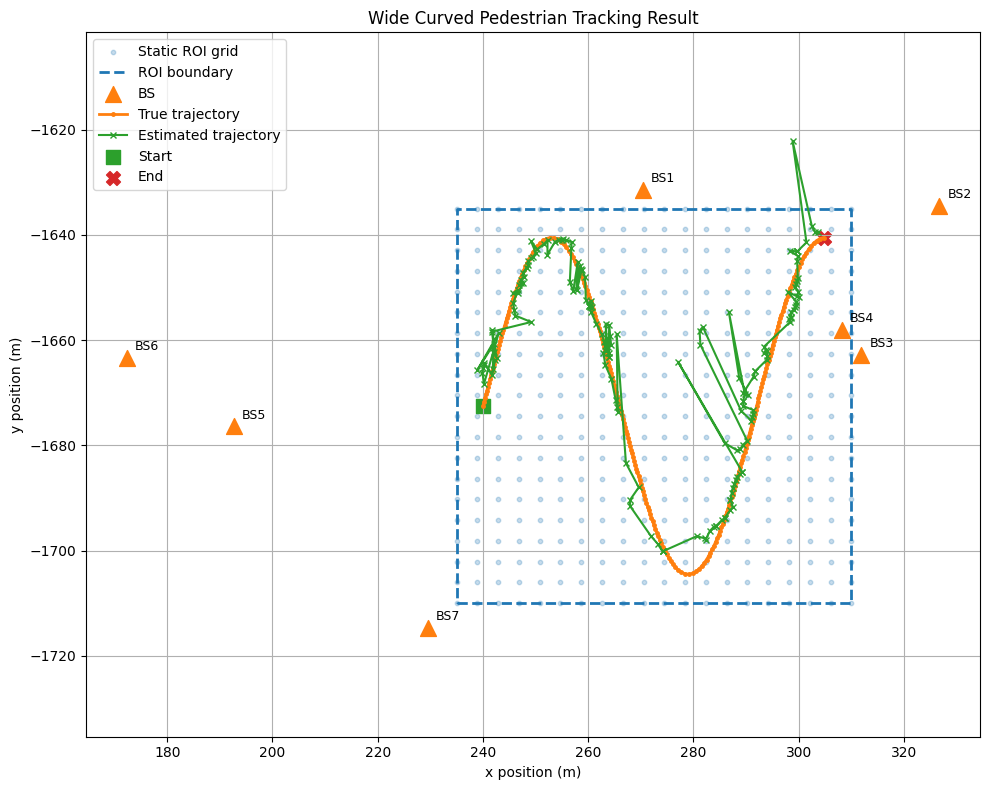

In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("/home/yerim/isac_tracking_wide_curved_result.pkl", "rb") as f:
    data = pickle.load(f)

true_traj = np.array(data["true_trajectory"])
results = data["trajectory_results"]
all_bs = np.array(data["all_bs"])
roi = data["ROI"]

X_MIN = roi["X_MIN"]
X_MAX = roi["X_MAX"]
Y_MIN = roi["Y_MIN"]
Y_MAX = roi["Y_MAX"]

pred_pts = []
true_valid = []
errors = []

for r in results:
    if r["pred_pos"] is not None:
        pred_pts.append(r["pred_pos"])
        true_valid.append(r["true_pos"])
        errors.append(r["error"])

pred_pts = np.array(pred_pts)
true_valid = np.array(true_valid)
errors = np.array(errors)

x_range = np.linspace(X_MIN, X_MAX, 20)
y_range = np.linspace(Y_MIN, Y_MAX, 20)
X, Y = np.meshgrid(x_range, y_range)

plt.figure(figsize=(10, 8))

# Static ROI grid
plt.scatter(
    X.flatten(),
    Y.flatten(),
    s=10,
    alpha=0.25,
    label="Static ROI grid"
)

# ROI boundary
plt.plot(
    [X_MIN, X_MAX, X_MAX, X_MIN, X_MIN],
    [Y_MIN, Y_MIN, Y_MAX, Y_MAX, Y_MIN],
    linestyle="--",
    linewidth=2,
    label="ROI boundary"
)

# BS
plt.scatter(
    all_bs[:, 0],
    all_bs[:, 1],
    marker="^",
    s=130,
    label="BS"
)

for i, bs in enumerate(all_bs):
    plt.text(bs[0] + 1.5, bs[1] + 1.5, f"BS{i+1}", fontsize=9)

# True trajectory
plt.plot(
    true_traj[:, 0],
    true_traj[:, 1],
    marker="o",
    markersize=2.5,
    linewidth=2,
    label="True trajectory"
)

# Estimated trajectory
if len(pred_pts) > 0:
    plt.plot(
        pred_pts[:, 0],
        pred_pts[:, 1],
        marker="x",
        markersize=4,
        linewidth=1.5,
        label="Estimated trajectory"
    )

# Start / End
plt.scatter(
    true_traj[0, 0],
    true_traj[0, 1],
    marker="s",
    s=90,
    label="Start"
)

plt.scatter(
    true_traj[-1, 0],
    true_traj[-1, 1],
    marker="X",
    s=100,
    label="End"
)

plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.title("Wide Curved Pedestrian Tracking Result")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Ground-Level UE-Free Human Tracking
# BS-Coverage-Wide Curved Trajectory Version
# Digital Twin Prior Channel Difference + Multilateration
# ============================================================

import mitsuba as mi
mi.set_variant("llvm_ad_mono_polarized")

import numpy as np
import time
import pickle
from scipy.optimize import minimize

from sionna.rt import (
    load_scene, Transmitter, Receiver, PlanarArray,
    PathSolver, RadioMaterial, SceneObject
)

# ============================================================
# Reproducibility
# ============================================================

np.random.seed(42)

c = 3e8
CARRIER_FREQ = 3.5e9

# ============================================================
# STEP 1. Scene Load
# ============================================================

scene = load_scene("/home/yerim/Downloads/material_NEW_seongbuk(1).xml")

scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V"
)

scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V"
)

print(f"📡 Carrier frequency: {CARRIER_FREQ/1e9:.2f} GHz")

# ============================================================
# STEP 2. BS Deployment
# ============================================================

BS_Z = 50.0
TARGET_Z = 20.0

all_bs = [
    [270.370, -1631.474, BS_Z],
    [326.736, -1634.541, BS_Z],
    [311.936, -1662.765, BS_Z],
    [308.222, -1657.997, BS_Z],
    [192.678, -1676.419, BS_Z],
    [172.344, -1663.427, BS_Z],
    [229.612, -1714.744, BS_Z],
]

rx_offsets = [[1.0, 0.0]] * len(all_bs)

for i, (bp, offset) in enumerate(zip(all_bs, rx_offsets)):
    scene.add(
        Transmitter(
            f"tx{i+1}",
            position=bp
        )
    )

    scene.add(
        Receiver(
            f"rx{i+1}",
            position=[
                bp[0] + offset[0],
                bp[1] + offset[1],
                bp[2]
            ]
        )
    )

print(f"✅ BS {len(all_bs)}개 배치")

# ============================================================
# STEP 3. Human Material
# ============================================================

human_mat = RadioMaterial(
    "human",
    relative_permittivity=40.0,
    conductivity=0.8,
    scattering_coefficient=0.5,
    thickness=0.1
)

scene.add(human_mat)
solver = PathSolver()

# ============================================================
# STEP 4. H_prior Calculation
# ============================================================

print("\nH_prior 계산 중...")

try:
    scene.edit(remove="target")
except:
    pass

paths_prior = solver(
    scene,
    synthetic_array=True,
    max_depth=3,
    los=True,
    specular_reflection=True,
    diffuse_reflection=False,
    seed=42
)

a_prior, tau_prior = paths_prior.cir(
    normalize_delays=False,
    out_type="numpy"
)

prior_dists_all = {}

for bs_idx in range(len(all_bs)):
    dists = set()

    for i in range(a_prior.shape[4]):
        t = float(tau_prior[bs_idx, bs_idx, i])

        if t > 0:
            dists.add(t * c / 2)

    prior_dists_all[bs_idx] = dists

print("✅ H_prior 완료")
print(f"✅ H_prior shape = {a_prior.shape}")

# ============================================================
# STEP 5. BS-Coverage-Wide Pedestrian Trajectory
# ============================================================
# BS5/BS6 근처에서 시작하여 7개 기지국 커버리지 내부를 크게 이동
# arclength 기반으로 재샘플링하여 실제 속도 1.5 m/s 유지

walking_speed = 1.5
dt = 0.5

# 넓은 tracking ROI
X_MIN, X_MAX = 185.0, 315.0
Y_MIN, Y_MAX = -1715.0, -1635.0

# 보행자가 지나갈 주요 waypoint
waypoints = np.array([
    [195.0, -1676.0],  # BS5 근처 시작
    [225.0, -1685.0],  # 중앙 아래쪽으로 진입
    [250.0, -1655.0],  # 중앙 상단
    [275.0, -1645.0],  # BS1 근처
    [305.0, -1660.0],  # BS3/BS4 근처
    [285.0, -1695.0],  # 아래쪽으로 곡선 이동
    [245.0, -1705.0],  # BS7 방향
    [220.0, -1680.0],  # 다시 좌측 중앙
    [260.0, -1665.0],  # 중앙 복귀
], dtype=float)

# waypoint 사이 dense path 생성
dense_points = []

for i in range(len(waypoints) - 1):
    p0 = waypoints[i]
    p1 = waypoints[i + 1]

    n_seg = 200
    for s in np.linspace(0, 1, n_seg, endpoint=False):
        p = (1 - s) * p0 + s * p1
        dense_points.append(p)

dense_points.append(waypoints[-1])
dense_points = np.array(dense_points)

# 약간의 곡선 offset 추가
for i in range(len(dense_points)):
    phase = 2 * np.pi * i / len(dense_points)
    dense_points[i, 0] += 2.0 * np.sin(3 * phase)
    dense_points[i, 1] += 2.0 * np.cos(2 * phase)

# ROI 밖으로 나가지 않게 제한
dense_points[:, 0] = np.clip(dense_points[:, 0], X_MIN, X_MAX)
dense_points[:, 1] = np.clip(dense_points[:, 1], Y_MIN, Y_MAX)

# arclength 계산
diffs = np.diff(dense_points, axis=0)
seg_lengths = np.linalg.norm(diffs, axis=1)
cum_len = np.concatenate([[0.0], np.cumsum(seg_lengths)])
total_len = cum_len[-1]

# walking speed와 dt에 맞게 일정 거리 간격으로 샘플링
step_dist = walking_speed * dt
sample_dists = np.arange(0.0, total_len, step_dist)

x_sample = np.interp(sample_dists, cum_len, dense_points[:, 0])
y_sample = np.interp(sample_dists, cum_len, dense_points[:, 1])

positions = np.stack(
    [x_sample, y_sample, np.full_like(x_sample, TARGET_Z)],
    axis=1
)

num_steps = len(positions)
duration = (num_steps - 1) * dt

true_trajectory = []
true_velocities = []

# velocity 계산
for step in range(num_steps):
    if step == 0:
        vel = (positions[1] - positions[0]) / dt
    elif step == num_steps - 1:
        vel = (positions[-1] - positions[-2]) / dt
    else:
        vel = (positions[step + 1] - positions[step - 1]) / (2 * dt)

    vel_xy = vel[:2]
    norm_v = np.linalg.norm(vel_xy)

    if norm_v > 1e-9:
        vel_xy = vel_xy / norm_v * walking_speed
    else:
        vel_xy = np.array([0.0, 0.0])

    true_trajectory.append(positions[step].tolist())
    true_velocities.append([vel_xy[0], vel_xy[1], 0.0])

print("✅ BS coverage-wide 보행자 경로 생성 완료")
print(f"   총 경로 길이: {total_len:.1f} m")
print(f"   추적 시간:   {duration:.1f} s")
print(f"   총 step:     {num_steps}")
print(f"   ROI: x={X_MIN}~{X_MAX}, y={Y_MIN}~{Y_MAX}")

# ============================================================
# STEP 6. Add Target Function
# ============================================================

def add_target(x, y, vx=0.0, vy=0.0, z=TARGET_Z):
    """
    Ground-level pedestrian target.
    z는 지면 높이.
    cuboid 중심을 z+0.85에 둬서 발이 지면에 닿도록 설정.
    """

    try:
        scene.edit(remove="target")
    except:
        pass

    box_mesh = mi.load_dict({
        "type": "cube",
        "to_world": (
            mi.ScalarTransform4f.translate([
                float(x),
                float(y),
                float(z + 0.85)
            ])
            @
            mi.ScalarTransform4f.scale([
                0.3,
                0.3,
                0.85
            ])
        )
    })

    target_obj = SceneObject(
        mi_mesh=box_mesh,
        name="target",
        radio_material=human_mat
    )

    scene.edit(add=target_obj)

    # Doppler 효과 반영
    scene.get("target").velocity = [
        float(vx),
        float(vy),
        0.0
    ]

# ============================================================
# STEP 7. Multilateration Initial Points
# ============================================================

x_init = np.arange(X_MIN, X_MAX + 1, 10.0)
y_init = np.arange(Y_MIN, Y_MAX + 1, 10.0)

init_points = [
    [x, y]
    for x in x_init
    for y in y_init
]

print(f"✅ Multilateration 초기값: {len(init_points)}개")

# ============================================================
# STEP 8. Parameters
# ============================================================

MIN_BS = 3
CLUTTER_THRESH = 1.0
MAX_RANGE_HORIZ = 140.0
AMP_THRESH = 1e-10

MOTION_WEIGHT = 0.2
JUMP_THRESHOLD = 25.0

print(f"✅ MIN_BS = {MIN_BS}")
print(f"✅ CLUTTER_THRESH = {CLUTTER_THRESH} m")
print(f"✅ MAX_RANGE_HORIZ = {MAX_RANGE_HORIZ} m")
print(f"✅ MOTION_WEIGHT = {MOTION_WEIGHT}")
print(f"✅ JUMP_THRESHOLD = {JUMP_THRESHOLD} m")

# ============================================================
# STEP 9. Real-Time Tracking
# ============================================================

trajectory_results = []
t_start = time.time()

print("\nBS coverage-wide 보행자 실시간 추적 시작...")
print("=" * 80)

for step in range(num_steps):

    pos = true_trajectory[step]
    vel_step = true_velocities[step]

    # --------------------------------------------------------
    # 1) Target 배치
    # --------------------------------------------------------

    add_target(
        pos[0],
        pos[1],
        vx=vel_step[0],
        vy=vel_step[1]
    )

    # --------------------------------------------------------
    # 2) H_meas 계산
    # --------------------------------------------------------

    paths_meas = solver(
        scene,
        synthetic_array=True,
        max_depth=3,
        los=True,
        specular_reflection=True,
        diffuse_reflection=True,
        seed=42
    )

    a_meas, tau_meas = paths_meas.cir(
        normalize_delays=False,
        out_type="numpy"
    )

    doppler = np.array(paths_meas.doppler)

    # --------------------------------------------------------
    # 3) H_meas - H_prior 차분 기반 신규 path 추출
    # --------------------------------------------------------

    ranges = []
    dopplers = []

    for bs_idx in range(len(all_bs)):

        bp = all_bs[bs_idx]
        dz_bs = abs(bp[2] - TARGET_Z)
        prior_dists = prior_dists_all[bs_idx]

        new_paths = []

        for i in range(a_meas.shape[4]):

            t = float(tau_meas[bs_idx, bs_idx, i])

            if t <= 0:
                continue

            dist = t * c / 2

            a_m = float(
                np.abs(a_meas)[
                    bs_idx,
                    0,
                    bs_idx,
                    0,
                    i,
                    0
                ]
            )

            if a_m <= AMP_THRESH:
                continue

            # 핵심 차분:
            # H_prior에 있던 경로면 버리고,
            # H_prior에 없던 경로면 사람 때문에 생긴 new path로 판단
            is_new = not any(
                abs(dist - pd) < CLUTTER_THRESH
                for pd in prior_dists
            )

            if is_new:
                try:
                    f_doppler = float(doppler[bs_idx, bs_idx, i])
                except:
                    f_doppler = 0.0

                new_paths.append(
                    (dist, a_m, f_doppler)
                )

        # ----------------------------------------------------
        # 4) Candidate path 선택
        # ----------------------------------------------------

        if new_paths:

            # 동적 tracking에서는 거리와 amplitude를 함께 고려
            best = min(
                new_paths,
                key=lambda v: v[0] / (v[1] + 1e-9)
            )

            if best[0] >= dz_bs:

                r_horiz = np.sqrt(best[0]**2 - dz_bs**2)

                if r_horiz > MAX_RANGE_HORIZ:
                    continue

                ranges.append(
                    (bs_idx, r_horiz)
                )

                dopplers.append(best[2])

    # --------------------------------------------------------
    # 5) Multilateration
    # --------------------------------------------------------

    pred_pos = None
    error = None
    best_cost = None

    if len(ranges) >= MIN_BS:

        bs_2d = np.array([
            [bp[0], bp[1]]
            for bp in all_bs
        ])

        prev_results = [
            r for r in trajectory_results
            if r["pred_pos"] is not None
        ]

        prev_pred = None

        if prev_results:
            prev_pred = np.array(
                prev_results[-1]["pred_pos"]
            )

        def cost(p):

            range_error = sum(
                (
                    np.sqrt(
                        (p[0] - bs_2d[idx][0])**2 +
                        (p[1] - bs_2d[idx][1])**2
                    ) - r
                )**2
                for idx, r in ranges
            )

            motion_penalty = 0.0

            if prev_pred is not None:
                motion_penalty = (
                    MOTION_WEIGHT *
                    np.linalg.norm(p - prev_pred)**2
                )

            return range_error + motion_penalty

        # 이전 위치 주변 초기값 + 전체 ROI 초기값
        if prev_pred is not None:

            local_inits = [
                prev_pred + np.random.randn(2) * 3
                for _ in range(30)
            ]

            local_inits.append(prev_pred.tolist())

            search_points = local_inits + init_points

        else:
            search_points = init_points

        best_result = None
        best_cost_val = float("inf")

        for x0 in search_points:

            result = minimize(
                cost,
                x0,
                method="Nelder-Mead",
                options={
                    "xatol": 0.01,
                    "fatol": 0.01,
                    "maxiter": 10000
                }
            )

            if result.fun < best_cost_val:
                best_cost_val = result.fun
                best_result = result

        pred_pos = best_result.x.tolist()
        best_cost = float(best_cost_val)

        # 너무 큰 순간 jump만 억제
        if prev_pred is not None:
            jump = np.linalg.norm(
                np.array(pred_pos) - prev_pred
            )

            if jump > JUMP_THRESHOLD:
                pred_pos = prev_pred.tolist()
                print(f"  ⚠️ Jump {jump:.1f}m 감지 → 이전 위치 유지")

        error = float(
            np.sqrt(
                (pred_pos[0] - pos[0])**2 +
                (pred_pos[1] - pos[1])**2
            )
        )

    # --------------------------------------------------------
    # 6) Doppler summary
    # --------------------------------------------------------

    if dopplers:

        speed_per_bs = [
            abs(d) * c / (2 * CARRIER_FREQ)
            for d in dopplers
        ]

        estimated_speed = float(
            np.median(speed_per_bs)
        )

        avg_abs_doppler = float(
            np.mean([abs(d) for d in dopplers])
        )

    else:
        estimated_speed = 0.0
        avg_abs_doppler = 0.0

    trajectory_results.append({
        "step": step,
        "time": step * dt,
        "true_pos": pos[:2],
        "true_velocity": vel_step[:2],
        "pred_pos": pred_pos,
        "error": error,
        "n_bs": len(ranges),
        "ranges": [
            (int(idx), float(r))
            for idx, r in ranges
        ],
        "avg_abs_doppler": avg_abs_doppler,
        "est_speed": estimated_speed,
        "best_cost": best_cost
    })

    # --------------------------------------------------------
    # 7) Print status
    # --------------------------------------------------------

    if pred_pos is not None:
        status = (
            f"추정: ({pred_pos[0]:.1f}, {pred_pos[1]:.1f}) | "
            f"오차: {error:.2f}m"
        )
    else:
        status = "추정 불가"

    print(
        f"t={step*dt:5.1f}s | "
        f"실제: ({pos[0]:.1f}, {pos[1]:.1f}) | "
        f"{status} | "
        f"BS={len(ranges)} | "
        f"|f_d|={avg_abs_doppler:.1f}Hz | "
        f"v_est={estimated_speed:.2f}m/s"
    )

# ============================================================
# STEP 10. Statistics
# ============================================================

elapsed = time.time() - t_start

errors = [
    r["error"]
    for r in trajectory_results
    if r["error"] is not None
]

speeds = [
    r["est_speed"]
    for r in trajectory_results
    if r["n_bs"] >= MIN_BS
]

errors_np = np.array(errors)

print("\n" + "=" * 80)
print("BS coverage-wide 보행자 실시간 추적 결과")
print("=" * 80)

print(f"추적 시간:        {duration:.1f}초")
print(f"총 step:          {num_steps}")
print(f"유효 샘플:        {len(errors_np)}/{num_steps}")

if len(errors_np) > 0:
    print(f"평균 오차:        {np.mean(errors_np):.2f} m")
    print(f"중앙값 오차:      {np.median(errors_np):.2f} m")
    print(f"RMSE:             {np.sqrt(np.mean(errors_np**2)):.2f} m")
    print(f"P90 오차:         {np.percentile(errors_np, 90):.2f} m")
    print(f"최대 오차:        {np.max(errors_np):.2f} m")

    print(f"\n< 1m 비율:        {np.mean(errors_np < 1.0)*100:.1f}%")
    print(f"< 2m 비율:        {np.mean(errors_np < 2.0)*100:.1f}%")
    print(f"< 5m 비율:        {np.mean(errors_np < 5.0)*100:.1f}%")
    print(f"< 10m 비율:       {np.mean(errors_np < 10.0)*100:.1f}%")

if len(speeds) > 0:
    print(f"\n실제 속도:        {walking_speed:.2f} m/s")
    print(f"추정 속도 median: {np.median(speeds):.2f} m/s")
    print(f"추정 속도 mean:   {np.mean(speeds):.2f} m/s")
    print(f"추정 속도 범위:   {np.min(speeds):.2f} ~ {np.max(speeds):.2f} m/s")

print(f"\n총 소요 시간:     {elapsed:.1f}초")
print(f"step당 시간:      {elapsed/num_steps:.2f}초")

# ============================================================
# STEP 11. Save
# ============================================================

with open("/home/yerim/isac_tracking_bs_coverage_wide_result.pkl", "wb") as f:
    pickle.dump({
        "true_trajectory": true_trajectory,
        "true_velocities": true_velocities,
        "trajectory_results": trajectory_results,
        "all_bs": all_bs,
        "walking_speed": walking_speed,
        "duration": duration,
        "dt": dt,
        "BS_Z": BS_Z,
        "TARGET_Z": TARGET_Z,
        "carrier_freq": CARRIER_FREQ,
        "MIN_BS": MIN_BS,
        "CLUTTER_THRESH": CLUTTER_THRESH,
        "MAX_RANGE_HORIZ": MAX_RANGE_HORIZ,
        "MOTION_WEIGHT": MOTION_WEIGHT,
        "JUMP_THRESHOLD": JUMP_THRESHOLD,
        "ROI": {
            "X_MIN": X_MIN,
            "X_MAX": X_MAX,
            "Y_MIN": Y_MIN,
            "Y_MAX": Y_MAX
        },
        "trajectory_type": "BS5/BS6-start wide coverage trajectory"
    }, f)

print("\n✅ 저장 완료: /home/yerim/isac_tracking_bs_coverage_wide_result.pkl")

📡 Carrier frequency: 3.50 GHz
✅ BS 7개 배치

H_prior 계산 중...
✅ H_prior 완료
✅ H_prior shape = (7, 1, 7, 1, 19, 1)
✅ BS coverage-wide 보행자 경로 생성 완료
   총 경로 길이: 296.3 m
   추적 시간:   197.5 s
   총 step:     396
   ROI: x=185.0~315.0, y=-1715.0~-1635.0
✅ Multilateration 초기값: 126개
✅ MIN_BS = 3
✅ CLUTTER_THRESH = 1.0 m
✅ MAX_RANGE_HORIZ = 140.0 m
✅ MOTION_WEIGHT = 0.2
✅ JUMP_THRESHOLD = 25.0 m

BS coverage-wide 보행자 실시간 추적 시작...
t=  0.0s | 실제: (195.0, -1674.0) | 추정 불가 | BS=1 | |f_d|=22.7Hz | v_est=0.97m/s
t=  0.5s | 실제: (195.7, -1674.2) | 추정 불가 | BS=1 | |f_d|=22.9Hz | v_est=0.98m/s
t=  1.0s | 실제: (196.5, -1674.4) | 추정 불가 | BS=0 | |f_d|=0.0Hz | v_est=0.00m/s
t=  1.5s | 실제: (197.2, -1674.6) | 추정 불가 | BS=0 | |f_d|=0.0Hz | v_est=0.00m/s
t=  2.0s | 실제: (197.9, -1674.8) | 추정 불가 | BS=0 | |f_d|=0.0Hz | v_est=0.00m/s
t=  2.5s | 실제: (198.6, -1675.0) | 추정 불가 | BS=0 | |f_d|=0.0Hz | v_est=0.00m/s
t=  3.0s | 실제: (199.3, -1675.2) | 추정 불가 | BS=0 | |f_d|=0.0Hz | v_est=0.00m/s
t=  3.5s | 실제: (200.1, -1675.4) | 추정 불가 |

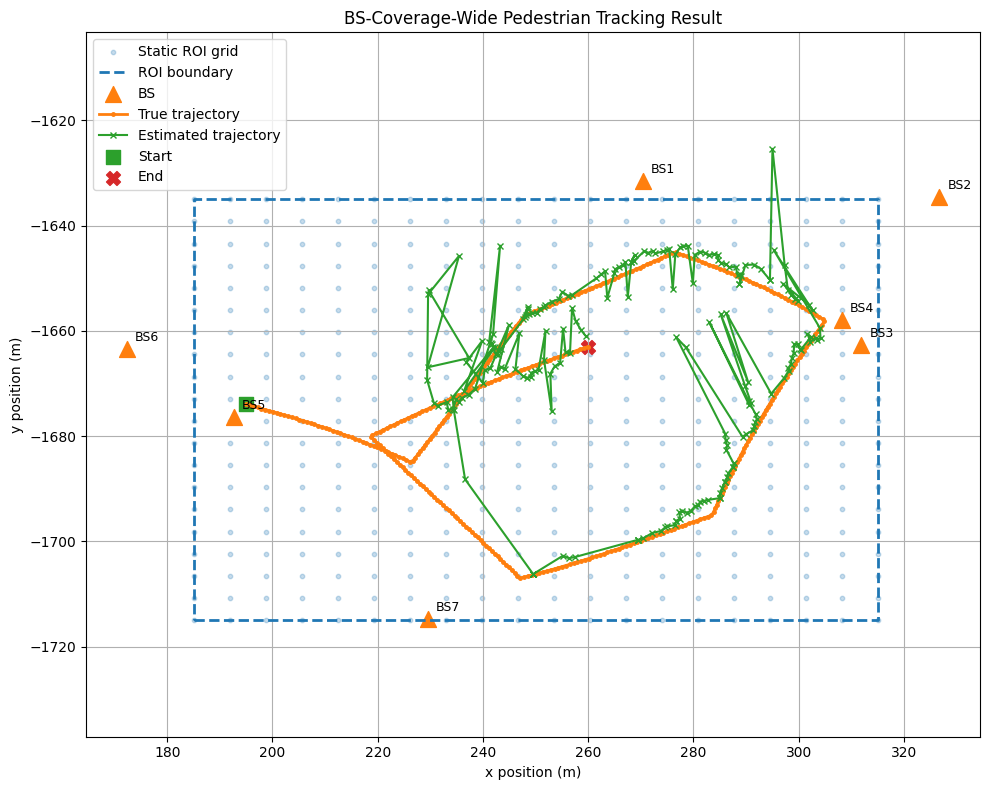

In [11]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("/home/yerim/isac_tracking_bs_coverage_wide_result.pkl", "rb") as f:
    data = pickle.load(f)

true_traj = np.array(data["true_trajectory"])
results = data["trajectory_results"]
all_bs = np.array(data["all_bs"])
roi = data["ROI"]

X_MIN = roi["X_MIN"]
X_MAX = roi["X_MAX"]
Y_MIN = roi["Y_MIN"]
Y_MAX = roi["Y_MAX"]

pred_pts = []
true_valid = []
errors = []

for r in results:
    if r["pred_pos"] is not None:
        pred_pts.append(r["pred_pos"])
        true_valid.append(r["true_pos"])
        errors.append(r["error"])

pred_pts = np.array(pred_pts)
true_valid = np.array(true_valid)
errors = np.array(errors)

# Static grid visualization only
x_range = np.linspace(X_MIN, X_MAX, 20)
y_range = np.linspace(Y_MIN, Y_MAX, 20)
X, Y = np.meshgrid(x_range, y_range)

plt.figure(figsize=(10, 8))

# ROI grid
plt.scatter(
    X.flatten(),
    Y.flatten(),
    s=10,
    alpha=0.25,
    label="Static ROI grid"
)

# ROI boundary
plt.plot(
    [X_MIN, X_MAX, X_MAX, X_MIN, X_MIN],
    [Y_MIN, Y_MIN, Y_MAX, Y_MAX, Y_MIN],
    linestyle="--",
    linewidth=2,
    label="ROI boundary"
)

# BS
plt.scatter(
    all_bs[:, 0],
    all_bs[:, 1],
    marker="^",
    s=130,
    label="BS"
)

for i, bs in enumerate(all_bs):
    plt.text(bs[0] + 1.5, bs[1] + 1.5, f"BS{i+1}", fontsize=9)

# True trajectory
plt.plot(
    true_traj[:, 0],
    true_traj[:, 1],
    marker="o",
    markersize=2.5,
    linewidth=2,
    label="True trajectory"
)

# Estimated trajectory
if len(pred_pts) > 0:
    plt.plot(
        pred_pts[:, 0],
        pred_pts[:, 1],
        marker="x",
        markersize=4,
        linewidth=1.5,
        label="Estimated trajectory"
    )

# Start / End
plt.scatter(
    true_traj[0, 0],
    true_traj[0, 1],
    marker="s",
    s=90,
    label="Start"
)

plt.scatter(
    true_traj[-1, 0],
    true_traj[-1, 1],
    marker="X",
    s=100,
    label="End"
)

plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.title("BS-Coverage-Wide Pedestrian Tracking Result")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
import pickle
import numpy as np

with open('/home/yerim/isac_static_roi_400_result.pkl', 'rb') as f:
    data = pickle.load(f)

errors_raw = np.array(data['errors'])
dataset = data['dataset']

# ROI 경계 밖 = 실패로 처리
X_MIN, X_MAX = 220.0, 305.0
Y_MIN, Y_MAX = -1700.0, -1630.0

errors_filtered = []
rejected = 0

for d in dataset:
    pred = d['pred_position']
    err = d['error']
    if pred is None or err is None:
        continue
    if (pred[0] < X_MIN or pred[0] > X_MAX or
        pred[1] < Y_MIN or pred[1] > Y_MAX):
        rejected += 1
        continue
    errors_filtered.append(err)

errors_filtered = np.array(errors_filtered)

print(f"제거된 outlier: {rejected}개")
print(f"유효 샘플: {len(errors_filtered)}/400")
print(f"Median: {np.median(errors_filtered):.2f} m")
print(f"RMSE:   {np.sqrt(np.mean(errors_filtered**2)):.2f} m")
print(f"P90:    {np.percentile(errors_filtered, 90):.2f} m")
print(f"Max:    {np.max(errors_filtered):.2f} m")
print(f"< 2m:   {np.mean(errors_filtered<2)*100:.1f}%")

제거된 outlier: 1개
유효 샘플: 324/400
Median: 1.55 m
RMSE:   2.35 m
P90:    2.59 m
Max:    24.02 m
< 2m:   69.4%


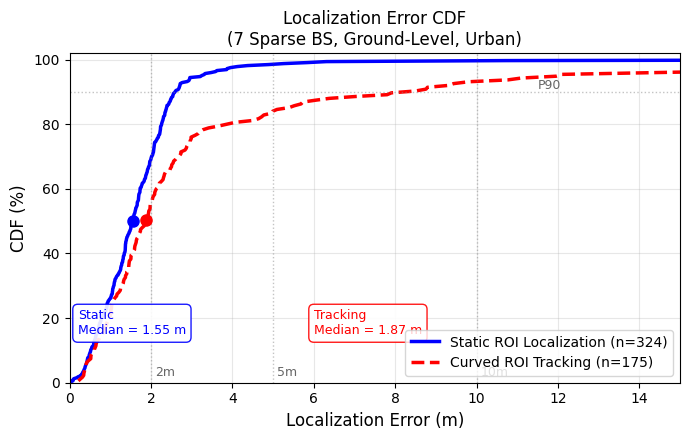

✅ 저장 완료: fig3_cdf.png
Static  Median: 1.55m | P90: 2.59m
Tracking Median: 1.87m | P90: 8.26m


In [17]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 데이터 로드
# ============================================================
with open('/home/yerim/isac_static_roi_400_result.pkl', 'rb') as f:
    static_data = pickle.load(f)
with open('/home/yerim/isac_tracking_wide_curved_result.pkl', 'rb') as f:
    track_data = pickle.load(f)

# Static: outlier 제거 (ROI 밖 1개)
X_MIN, X_MAX = 220.0, 305.0
Y_MIN, Y_MAX = -1700.0, -1630.0

static_errors = []
for d in static_data['dataset']:
    pred = d['pred_position']
    err = d['error']
    if pred is None or err is None:
        continue
    if (pred[0] < X_MIN or pred[0] > X_MAX or
        pred[1] < Y_MIN or pred[1] > Y_MAX):
        continue
    static_errors.append(err)

track_errors = [r['error'] for r in track_data['trajectory_results']
                if r['error'] is not None]

static_errors = np.sort(np.array(static_errors))
track_errors  = np.sort(np.array(track_errors))

# ============================================================
# CDF 계산
# ============================================================
y_s = np.arange(1, len(static_errors)+1) / len(static_errors) * 100
y_t = np.arange(1, len(track_errors)+1)  / len(track_errors)  * 100

med_s = np.median(static_errors)
med_t = np.median(track_errors)
pct_s = np.sum(static_errors <= med_s) / len(static_errors) * 100
pct_t = np.sum(track_errors  <= med_t) / len(track_errors)  * 100

# ============================================================
# 그래프
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(static_errors, y_s, 'b-',  linewidth=2.5,
        label=f'Static ROI Localization (n={len(static_errors)})')
ax.plot(track_errors,  y_t, 'r--', linewidth=2.5,
        label=f'Curved ROI Tracking (n={len(track_errors)})')

# 임계값 수직선
for thresh in [2, 5, 10]:
    ax.axvline(x=thresh, color='#888888', linestyle=':', alpha=0.5, linewidth=1)
    ax.text(thresh + 0.1, 2, f'{thresh}m', fontsize=9, color='#666666')

# P90 수평선
ax.axhline(y=90, color='#888888', linestyle=':', alpha=0.5, linewidth=1)
ax.text(11.5, 91, 'P90', fontsize=9, color='#666666')

# Median 점
ax.plot(med_s, pct_s, 'o', color='blue', markersize=8, zorder=5)
ax.plot(med_t, pct_t, 'o', color='red',  markersize=8, zorder=5)

# ⭐ 텍스트 박스 (화살표 없음, 위치 완전 분리)
ax.text(0.2, 15,
        f'Static\nMedian = {med_s:.2f} m',
        fontsize=9, color='blue',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='white', edgecolor='blue', alpha=0.9))

ax.text(6.0, 15,
        f'Tracking\nMedian = {med_t:.2f} m',
        fontsize=9, color='red',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='white', edgecolor='red', alpha=0.9))

# 축 설정
ax.set_xlabel('Localization Error (m)', fontsize=12)
ax.set_ylabel('CDF (%)', fontsize=12)
ax.set_title('Localization Error CDF\n(7 Sparse BS, Ground-Level, Urban)', fontsize=12)
ax.set_xlim([0, 15])
ax.set_ylim([0, 102])
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/yerim/fig3_cdf.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ 저장 완료: fig3_cdf.png")
print(f"Static  Median: {med_s:.2f}m | P90: {np.percentile(static_errors, 90):.2f}m")
print(f"Tracking Median: {med_t:.2f}m | P90: {np.percentile(track_errors, 90):.2f}m")

In [1]:
import mitsuba as mi
mi.set_variant("llvm_ad_mono_polarized")
import numpy as np
import time
import pickle
from scipy.optimize import minimize
from sionna.rt import (load_scene, Transmitter, Receiver, PlanarArray,
                       PathSolver, RadioMaterial, SceneObject)

np.random.seed(42)
c = 3e8
CARRIER_FREQ = 3.5e9

# ============================================================
# STEP 1. Scene Load
# ============================================================
scene = load_scene("/home/yerim/Downloads/material_NEW_seongbuk(1).xml")
scene.tx_array = PlanarArray(num_rows=1, num_cols=1,
                              vertical_spacing=0.5, horizontal_spacing=0.5,
                              pattern="iso", polarization="V")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1,
                              vertical_spacing=0.5, horizontal_spacing=0.5,
                              pattern="iso", polarization="V")

BS_Z = 50.0
TARGET_Z = 20.0

# ============================================================
# STEP 2. BS 배치 (Tracking과 동일)
# ============================================================
all_bs = [
    [270.370, -1631.474, BS_Z],
    [326.736, -1634.541, BS_Z],
    [311.936, -1662.765, BS_Z],
    [308.222, -1657.997, BS_Z],
    [192.678, -1676.419, BS_Z],
    [172.344, -1663.427, BS_Z],
    [229.612, -1714.744, BS_Z],
]
rx_offsets = [[1.0, 0.0]] * len(all_bs)

for i, (bp, offset) in enumerate(zip(all_bs, rx_offsets)):
    scene.add(Transmitter(f"tx{i+1}", position=bp))
    scene.add(Receiver(f"rx{i+1}",
                       position=[bp[0]+offset[0], bp[1]+offset[1], bp[2]]))
print(f"✅ BS {len(all_bs)}개 배치")

# ============================================================
# STEP 3. Human Material
# ============================================================
human_mat = RadioMaterial("human",
                          relative_permittivity=40.0,
                          conductivity=0.8,
                          scattering_coefficient=0.5,
                          thickness=0.1)
scene.add(human_mat)
solver = PathSolver()

# ============================================================
# STEP 4. H_prior
# ============================================================
print("H_prior 계산 중...")
try:
    scene.edit(remove="target")
except:
    pass

paths_prior = solver(scene, synthetic_array=True, max_depth=3,
                     los=True, specular_reflection=True,
                     diffuse_reflection=False, seed=42)
a_prior, tau_prior = paths_prior.cir(normalize_delays=False, out_type="numpy")

prior_dists_all = {}
for bs_idx in range(len(all_bs)):
    dists = set()
    for i in range(a_prior.shape[4]):
        t = float(tau_prior[bs_idx, bs_idx, i])
        if t > 0:
            dists.add(t * c / 2)
    prior_dists_all[bs_idx] = dists
print("✅ H_prior 완료")

# ============================================================
# STEP 5. Add Target
# ============================================================
def add_target(x, y, z=TARGET_Z):
    try:
        scene.edit(remove="target")
    except:
        pass
    box_mesh = mi.load_dict({
        "type": "cube",
        "to_world": (
            mi.ScalarTransform4f.translate([float(x), float(y), float(z + 0.85)])
            @ mi.ScalarTransform4f.scale([0.3, 0.3, 0.85])
        )
    })
    scene.edit(add=SceneObject(mi_mesh=box_mesh, name="target",
                               radio_material=human_mat))
    scene.get("target").velocity = [0.0, 0.0, 0.0]  # 정적

# ============================================================
# STEP 6. ⭐ Tracking과 동일한 영역 + 파라미터
# ============================================================
# Tracking 영역: X=235~310, Y=-1710~-1635
X_MIN, X_MAX = 235.0, 310.0
Y_MIN, Y_MAX = -1710.0, -1635.0

x_range = np.linspace(X_MIN, X_MAX, 20)
y_range = np.linspace(Y_MIN, Y_MAX, 20)
total_points = len(x_range) * len(y_range)

# 초기값도 같은 영역
x_init = np.arange(X_MIN, X_MAX + 1, 10.0)
y_init = np.arange(Y_MIN, Y_MAX + 1, 10.0)
init_points = [[x, y] for x in x_init for y in y_init]

# ⭐ Tracking과 동일한 파라미터
MIN_BS = 3
CLUTTER_THRESH = 1.0   # Tracking과 동일
MAX_RANGE_HORIZ = 140.0  # Tracking과 동일
AMP_THRESH = 1e-10

print(f"\n✅ 영역: x={X_MIN}~{X_MAX}, y={Y_MIN}~{Y_MAX}")
print(f"✅ 총 {total_points}개 격자점")
print(f"✅ CLUTTER_THRESH={CLUTTER_THRESH}, MAX_RANGE={MAX_RANGE_HORIZ}")
print(f"✅ 초기값: {len(init_points)}개")

# ============================================================
# STEP 7. Static 400-Point Localization
# ============================================================
dataset = []
errors = []
valid_bs_counts = []
t_start = time.time()
count = 0

print("\nStatic 400-point localization 시작...")
print("=" * 70)

for x in x_range:
    for y in y_range:
        count += 1
        add_target(x, y)

        paths_meas = solver(scene, synthetic_array=True, max_depth=3,
                           los=True, specular_reflection=True,
                           diffuse_reflection=True, seed=42)
        a_meas, tau_meas = paths_meas.cir(normalize_delays=False, out_type="numpy")
        doppler = np.array(paths_meas.doppler)

        ranges = []
        dopplers = []

        for bs_idx in range(len(all_bs)):
            bp = all_bs[bs_idx]
            dz_bs = abs(bp[2] - TARGET_Z)
            prior_dists = prior_dists_all[bs_idx]

            new_paths = []
            for i in range(a_meas.shape[4]):
                t = float(tau_meas[bs_idx, bs_idx, i])
                if t <= 0: continue
                dist = t * c / 2
                a_m = float(np.abs(a_meas)[bs_idx, 0, bs_idx, 0, i, 0])
                if a_m <= AMP_THRESH: continue
                is_new = not any(abs(dist - pd) < CLUTTER_THRESH
                                 for pd in prior_dists)
                if is_new:
                    try:
                        f_doppler = float(doppler[bs_idx, bs_idx, i])
                    except:
                        f_doppler = 0.0
                    new_paths.append((dist, a_m, f_doppler))

            # ⭐ Tracking과 동일한 hybrid path selection
            if new_paths:
                best = min(new_paths, key=lambda v: v[0] / (v[1] + 1e-9))
                if best[0] >= dz_bs:
                    r_horiz = np.sqrt(best[0]**2 - dz_bs**2)
                    if r_horiz > MAX_RANGE_HORIZ:
                        continue
                    ranges.append((bs_idx, r_horiz))
                    dopplers.append(best[2])

        valid_bs_counts.append(len(ranges))

        pred_pos = None
        error = None

        if len(ranges) >= MIN_BS:
            bs_2d = np.array([[bp[0], bp[1]] for bp in all_bs])

            def cost(p):
                return sum(
                    (np.sqrt((p[0]-bs_2d[idx][0])**2 +
                             (p[1]-bs_2d[idx][1])**2) - r)**2
                    for idx, r in ranges)

            best_result = None
            best_cost_val = float("inf")
            for x0 in init_points:
                result = minimize(cost, x0, method="Nelder-Mead",
                                 options={"xatol": 0.01, "fatol": 0.01,
                                          "maxiter": 10000})
                if result.fun < best_cost_val:
                    best_cost_val = result.fun
                    best_result = result

            pred_pos = best_result.x.tolist()
            error = float(np.sqrt((pred_pos[0]-x)**2 + (pred_pos[1]-y)**2))
            errors.append(error)

        dataset.append({
            "true_position": [float(x), float(y)],
            "pred_position": pred_pos,
            "error": error,
            "n_valid_bs": len(ranges),
        })

        elapsed = time.time() - t_start
        eta = (elapsed / count) * (total_points - count)
        print(f"{count:3d}/{total_points} | BS={len(ranges)} | "
              f"err={f'{error:.2f}m' if error else 'None':>8} | "
              f"{elapsed/60:.1f}min | ETA={eta/60:.1f}min", end="\r")

        if count % 50 == 0:
            with open("/home/yerim/isac_static_wide_400_partial.pkl", "wb") as f:
                pickle.dump({"dataset": dataset, "errors": errors}, f)
            print(f"\n💾 중간 저장: {count}/{total_points}")

# ============================================================
# STEP 8. 저장 + 결과
# ============================================================
with open("/home/yerim/isac_static_wide_400_result.pkl", "wb") as f:
    pickle.dump({
        "dataset": dataset,
        "errors": errors,
        "valid_bs_counts": valid_bs_counts,
        "all_bs": all_bs,
        "BS_Z": BS_Z,
        "TARGET_Z": TARGET_Z,
        "x_range": x_range.tolist(),
        "y_range": y_range.tolist(),
        "X_MIN": X_MIN, "X_MAX": X_MAX,
        "Y_MIN": Y_MIN, "Y_MAX": Y_MAX,
        "CLUTTER_THRESH": CLUTTER_THRESH,
        "MAX_RANGE_HORIZ": MAX_RANGE_HORIZ,
    }, f)

errors_np = np.array(errors)
print(f"\n\n{'='*70}")
print(f"Static Wide 400-point 결과")
print(f"{'='*70}")
print(f"유효 샘플:    {len(errors_np)}/{total_points} ({len(errors_np)/total_points*100:.1f}%)")
print(f"평균 BS 수:   {np.mean(valid_bs_counts):.2f}개")
print(f"평균 오차:    {np.mean(errors_np):.2f} m")
print(f"중앙값:       {np.median(errors_np):.2f} m")
print(f"RMSE:         {np.sqrt(np.mean(errors_np**2)):.2f} m")
print(f"P90:          {np.percentile(errors_np, 90):.2f} m")
print(f"Max:          {np.max(errors_np):.2f} m")
print(f"< 2m:         {np.mean(errors_np<2)*100:.1f}%")
print(f"< 5m:         {np.mean(errors_np<5)*100:.1f}%")
print(f"< 10m:        {np.mean(errors_np<10)*100:.1f}%")
print(f"\n✅ 저장: isac_static_wide_400_result.pkl")

✅ BS 7개 배치
H_prior 계산 중...
✅ H_prior 완료

✅ 영역: x=235.0~310.0, y=-1710.0~-1635.0
✅ 총 400개 격자점
✅ CLUTTER_THRESH=1.0, MAX_RANGE=140.0
✅ 초기값: 64개

Static 400-point localization 시작...
 50/400 | BS=4 | err=  11.52m | 3.1min | ETA=21.6min
💾 중간 저장: 50/400
100/400 | BS=7 | err=   0.76m | 6.6min | ETA=19.8min
💾 중간 저장: 100/400
150/400 | BS=3 | err=   1.79m | 10.0min | ETA=16.6min
💾 중간 저장: 150/400
200/400 | BS=5 | err=   1.82m | 13.9min | ETA=13.9min
💾 중간 저장: 200/400
250/400 | BS=4 | err=   0.70m | 18.0min | ETA=10.8min
💾 중간 저장: 250/400
300/400 | BS=6 | err=   0.48m | 21.9min | ETA=7.3minn
💾 중간 저장: 300/400
350/400 | BS=3 | err=   1.61m | 25.7min | ETA=3.7min
💾 중간 저장: 350/400
400/400 | BS=5 | err=   1.89m | 29.5min | ETA=0.0min
💾 중간 저장: 400/400


Static Wide 400-point 결과
유효 샘플:    296/400 (74.0%)
평균 BS 수:   3.63개
평균 오차:    7.82 m
중앙값:       1.98 m
RMSE:         15.67 m
P90:          24.09 m
Max:          90.56 m
< 2m:         50.0%
< 5m:         71.6%
< 10m:        79.4%

✅ 저장: isac_static_wide_400

In [2]:
import glob, os

for f in sorted(glob.glob("/home/yerim/*tracking*.pkl"), key=os.path.getmtime, reverse=True):
    size = os.path.getsize(f) / 1024
    print(f"{os.path.basename(f):50s} {size:.0f}KB")

print()
for f in sorted(glob.glob("/home/yerim/*static*.pkl"), key=os.path.getmtime, reverse=True):
    size = os.path.getsize(f) / 1024
    print(f"{os.path.basename(f):50s} {size:.0f}KB")

isac_tracking_bs_coverage_wide_result.pkl          110KB
isac_tracking_wide_curved_result.pkl               67KB
isac_tracking_curved_result.pkl                    17KB
isac_tracking_result_v2.pkl                        5KB
isac_tracking_result.pkl                           6KB

isac_static_wide_400_partial.pkl                   26KB
isac_static_wide_400_result.pkl                    27KB
isac_static_roi_400_bounded_result.pkl             64KB
isac_static_roi_400_bounded_partial.pkl            64KB
isac_static_roi_400_result.pkl                     62KB
isac_static_roi_400_result_partial.pkl             62KB
isac_static_400_result.pkl                         59KB
isac_static_400_result_partial.pkl                 59KB
isac_bistatic_final.pkl                            11KB
isac_bistatic_rxz_result.pkl                       35KB
isac_bistatic_result.pkl                           35KB
isac_bistatic_400.pkl                              966KB


In [3]:
import pickle
import numpy as np

with open("/home/yerim/isac_static_wide_400_result.pkl", "rb") as f:
    data = pickle.load(f)

dataset = data["dataset"]

valid = [d for d in dataset if d["error"] is not None]
valid_sorted = sorted(valid, key=lambda d: d["error"], reverse=True)

print("Top 10 worst Static Wide errors")
for i, d in enumerate(valid_sorted[:10]):
    pred = d["pred_position"]
    true = d["true_position"]
    outside = (
        pred[0] < data["X_MIN"] or pred[0] > data["X_MAX"] or
        pred[1] < data["Y_MIN"] or pred[1] > data["Y_MAX"]
    )
    print(
        f"{i+1}: true={true}, pred={pred}, "
        f"error={d['error']:.2f}m, BS={d['n_valid_bs']}, outside_roi={outside}"
    )

Top 10 worst Static Wide errors
1: true=[290.2631578947368, -1662.6315789473683], pred=[243.8590245415577, -1584.8688880673676], error=90.56m, BS=4, outside_roi=True
2: true=[290.2631578947368, -1666.578947368421], pred=[272.341231300064, -1602.103011464342], error=66.92m, BS=6, outside_roi=True
3: true=[246.8421052631579, -1686.3157894736842], pred=[204.53784341268255, -1733.4073009771037], error=63.30m, BS=3, outside_roi=True
4: true=[290.2631578947368, -1706.0526315789473], pred=[255.17280953745274, -1655.4768261156428], error=61.56m, BS=4, outside_roi=False
5: true=[286.3157894736842, -1706.0526315789473], pred=[256.5695664955548, -1655.91601531261], error=58.30m, BS=4, outside_roi=False
6: true=[250.78947368421052, -1694.2105263157894], pred=[243.15991249777133, -1639.0792103919403], error=55.66m, BS=5, outside_roi=False
7: true=[274.4736842105263, -1702.1052631578948], pred=[252.52885629468125, -1653.5755482703362], error=53.26m, BS=3, outside_roi=False
8: true=[294.2105263157895

Visualization-only jump filtering
VIS_JUMP_THRESH = 10.0 m
제거된 시각화 outlier 수: 8개
1: t=2.0s, jump=10.12m, error=1.37m, pred=[240.18896315958742, -1668.345444199705]
2: t=49.5s, jump=14.72m, error=16.95m, pred=[265.4113825338038, -1658.8577231229428]
3: t=86.5s, jump=24.28m, error=23.27m, pred=[277.0692993547521, -1664.1202576575542]
4: t=89.5s, jump=20.35m, error=20.87m, pred=[281.3173748440487, -1660.8696691069722]
5: t=90.0s, jump=22.83m, error=22.77m, pred=[281.1682379870168, -1658.2104558320475]
6: t=90.5s, jump=23.24m, error=22.58m, pred=[281.79132882780425, -1657.5066442266016]
7: t=95.5s, jump=15.77m, error=17.29m, pred=[286.74857058950107, -1654.7418511477752]
8: t=116.5s, jump=19.47m, error=19.85m, pred=[298.83964117699844, -1622.147038148463]


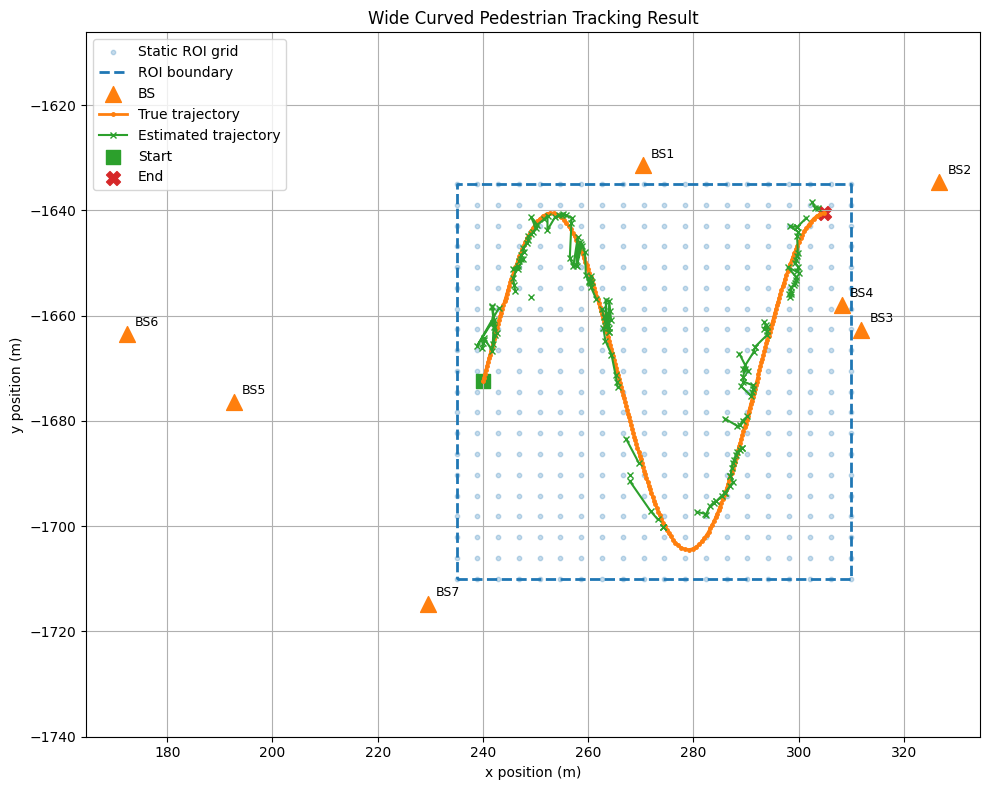

In [31]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Load original tracking result
# ============================================================

tracking_file = "/home/yerim/isac_tracking_wide_curved_result.pkl"

with open(tracking_file, "rb") as f:
    data = pickle.load(f)

results = data["trajectory_results"]
true_traj = np.array(data["true_trajectory"])
all_bs = np.array(data["all_bs"])

roi = data.get("ROI", None)

if roi is not None:
    X_MIN = roi["X_MIN"]
    X_MAX = roi["X_MAX"]
    Y_MIN = roi["Y_MIN"]
    Y_MAX = roi["Y_MAX"]
else:
    X_MIN, X_MAX = 235.0, 310.0
    Y_MIN, Y_MAX = -1710.0, -1635.0

# ============================================================
# 2. Visualization-only mild outlier filtering
# ============================================================

# 너무 많이 지워지면 15.0으로 올리기
# 너무 튄 점이 남으면 10.0으로 낮추기
VIS_JUMP_THRESH = 10 # meters

pred_vis = []
removed_points = []

prev_valid_pred = None

for r in results:
    pred = r["pred_pos"]

    if pred is None:
        pred_vis.append([np.nan, np.nan])
        continue

    pred_np = np.array(pred)

    if prev_valid_pred is not None:
        jump = np.linalg.norm(pred_np - prev_valid_pred)

        if jump > VIS_JUMP_THRESH:
            # 그림에서만 제거
            pred_vis.append([np.nan, np.nan])
            removed_points.append({
                "time": r["time"],
                "pred_pos": pred,
                "jump": jump,
                "error": r["error"]
            })
            # prev_valid_pred는 업데이트하지 않음
            continue

    pred_vis.append(pred)
    prev_valid_pred = pred_np

pred_vis = np.array(pred_vis)

print("=" * 60)
print("Visualization-only jump filtering")
print("=" * 60)
print(f"VIS_JUMP_THRESH = {VIS_JUMP_THRESH:.1f} m")
print(f"제거된 시각화 outlier 수: {len(removed_points)}개")

for i, p in enumerate(removed_points[:20]):
    print(
        f"{i+1}: t={p['time']:.1f}s, "
        f"jump={p['jump']:.2f}m, "
        f"error={p['error']:.2f}m, "
        f"pred={p['pred_pos']}"
    )

# ============================================================
# 3. Plot
# ============================================================

x_range = np.linspace(X_MIN, X_MAX, 20)
y_range = np.linspace(Y_MIN, Y_MAX, 20)
X, Y = np.meshgrid(x_range, y_range)

plt.figure(figsize=(10, 8))

# Static ROI grid
plt.scatter(
    X.flatten(),
    Y.flatten(),
    s=10,
    alpha=0.25,
    label="Static ROI grid"
)

# ROI boundary
plt.plot(
    [X_MIN, X_MAX, X_MAX, X_MIN, X_MIN],
    [Y_MIN, Y_MIN, Y_MAX, Y_MAX, Y_MIN],
    linestyle="--",
    linewidth=2,
    label="ROI boundary"
)

# BS
plt.scatter(
    all_bs[:, 0],
    all_bs[:, 1],
    marker="^",
    s=130,
    label="BS"
)

for i, bs in enumerate(all_bs):
    plt.text(bs[0] + 1.5, bs[1] + 1.5, f"BS{i+1}", fontsize=9)

# True trajectory
plt.plot(
    true_traj[:, 0],
    true_traj[:, 1],
    marker="o",
    markersize=2.5,
    linewidth=2,
    label="True trajectory"
)

# Estimated trajectory with mild filtering
plt.plot(
    pred_vis[:, 0],
    pred_vis[:, 1],
    marker="x",
    markersize=4,
    linewidth=1.5,
    label="Estimated trajectory"
)

# Start / End
plt.scatter(
    true_traj[0, 0],
    true_traj[0, 1],
    marker="s",
    s=90,
    label="Start"
)

plt.scatter(
    true_traj[-1, 0],
    true_traj[-1, 1],
    marker="X",
    s=100,
    label="End"
)

plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.title("Wide Curved Pedestrian Tracking Result")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
import pickle
import numpy as np

# ============================================================
# Load tracking result
# ============================================================

tracking_file = "/home/yerim/isac_tracking_wide_curved_result.pkl"

with open(tracking_file, "rb") as f:
    data = pickle.load(f)

results = data["trajectory_results"]

# ============================================================
# 1. Top worst error points
# ============================================================

valid_results = [
    r for r in results
    if r["pred_pos"] is not None and r["error"] is not None
]

worst_by_error = sorted(
    valid_results,
    key=lambda r: r["error"],
    reverse=True
)

print("=" * 80)
print("Top 20 worst Tracking errors")
print("=" * 80)

for i, r in enumerate(worst_by_error[:20]):
    print(
        f"{i+1:2d}: "
        f"t={r['time']:6.1f}s | "
        f"true={np.round(r['true_pos'], 2)} | "
        f"pred={np.round(r['pred_pos'], 2)} | "
        f"error={r['error']:6.2f}m | "
        f"BS={r['n_bs']}"
    )

# ============================================================
# 2. Top jump points between consecutive valid predictions
# ============================================================

jump_records = []

prev_pred = None
prev_time = None
prev_idx = None

for idx, r in enumerate(results):
    pred = r["pred_pos"]

    if pred is None:
        continue

    pred_np = np.array(pred)

    if prev_pred is not None:
        jump = np.linalg.norm(pred_np - prev_pred)
        dt_gap = r["time"] - prev_time

        jump_records.append({
            "idx": idx,
            "time": r["time"],
            "prev_time": prev_time,
            "dt_gap": dt_gap,
            "jump": jump,
            "true_pos": r["true_pos"],
            "pred_pos": r["pred_pos"],
            "error": r["error"],
            "n_bs": r["n_bs"],
            "prev_idx": prev_idx,
            "prev_pred": prev_pred.tolist(),
        })

    prev_pred = pred_np
    prev_time = r["time"]
    prev_idx = idx

worst_by_jump = sorted(
    jump_records,
    key=lambda x: x["jump"],
    reverse=True
)

print("\n" + "=" * 80)
print("Top 20 largest Tracking jumps")
print("=" * 80)

for i, r in enumerate(worst_by_jump[:20]):
    print(
        f"{i+1:2d}: "
        f"t={r['prev_time']:6.1f}s → {r['time']:6.1f}s | "
        f"dt={r['dt_gap']:4.1f}s | "
        f"jump={r['jump']:6.2f}m | "
        f"error={r['error']:6.2f}m | "
        f"BS={r['n_bs']} | "
        f"pred={np.round(r['pred_pos'], 2)}"
    )

# ============================================================
# 3. Check how many jumps exceed candidate thresholds
# ============================================================

print("\n" + "=" * 80)
print("Jump threshold count")
print("=" * 80)

for th in [5, 8, 10, 12, 15, 20]:
    count = sum(1 for r in jump_records if r["jump"] > th)
    print(f"jump > {th:2d}m : {count:3d} points")

# ============================================================
# 4. Error threshold count
# ============================================================

print("\n" + "=" * 80)
print("Error threshold count")
print("=" * 80)

errors = np.array([r["error"] for r in valid_results])

for th in [5, 8, 10, 12, 15, 20]:
    count = np.sum(errors > th)
    print(f"error > {th:2d}m : {count:3d} points")

Top 20 worst Tracking errors
 1: t=  86.5s | true=[  288.92 -1684.14] | pred=[  277.07 -1664.12] | error= 23.27m | BS=5
 2: t=  90.0s | true=[  290.29 -1679.07] | pred=[  281.17 -1658.21] | error= 22.77m | BS=4
 3: t=  90.5s | true=[  290.48 -1678.35] | pred=[  281.79 -1657.51] | error= 22.58m | BS=4
 4: t=  89.5s | true=[  290.1 -1679.8] | pred=[  281.32 -1660.87] | error= 20.87m | BS=4
 5: t= 116.5s | true=[  302.83 -1641.59] | pred=[  298.84 -1622.15] | error= 19.85m | BS=6
 6: t=  95.5s | true=[  292.36 -1671.09] | pred=[  286.75 -1654.74] | error= 17.29m | BS=3
 7: t=  49.5s | true=[  266.84 -1675.75] | pred=[  265.41 -1658.86] | error= 16.95m | BS=3
 8: t=   0.0s | true=[  240.  -1672.5] | pred=[  241.7  -1658.16] | error= 14.44m | BS=4
 9: t=  45.0s | true=[  265.15 -1669.21] | pred=[  263.99 -1657.16] | error= 12.10m | BS=5
10: t=   1.5s | true=[  240.56 -1670.32] | pred=[  243.01 -1658.62] | error= 11.95m | BS=4
11: t=   0.5s | true=[  240.19 -1671.77] | pred=[  242.01 -1660.8

Mild Tracking Jump Filtering
VIS_JUMP_THRESH = 12.0 m
MAX_DT_FOR_JUMP = 1.0 s
원본 유효 샘플:      175/237
제거된 jump outlier: 8
정제 후 유효 샘플:   167/237

제거된 점들:
1: t=49.5s | jump=14.72m | dt=0.5s | error=16.95m | BS=3 | pred=[  265.41 -1658.86]
2: t=86.5s | jump=24.28m | dt=0.5s | error=23.27m | BS=5 | pred=[  277.07 -1664.12]
3: t=89.5s | jump=20.35m | dt=0.5s | error=20.87m | BS=4 | pred=[  281.32 -1660.87]
4: t=90.0s | jump=22.83m | dt=1.0s | error=22.77m | BS=4 | pred=[  281.17 -1658.21]
5: t=91.0s | jump=17.51m | dt=0.5s | error=4.49m | BS=4 | pred=[  289.06 -1673.44]
6: t=91.5s | jump=20.04m | dt=1.0s | error=1.60m | BS=4 | pred=[  290.99 -1675.31]
7: t=95.5s | jump=15.77m | dt=0.5s | error=17.29m | BS=3 | pred=[  286.75 -1654.74]
8: t=116.5s | jump=19.47m | dt=0.5s | error=19.85m | BS=6 | pred=[  298.84 -1622.15]

[Original]
Median: 1.87 m
RMSE:   5.47 m
P90:    8.26 m
Max:    23.27 m
<10m:   93.1%

[Cleaned]
Median: 1.83 m
RMSE:   4.05 m
P90:    5.85 m
Max:    22.58 m
<10m:   96.4%

✅ 저

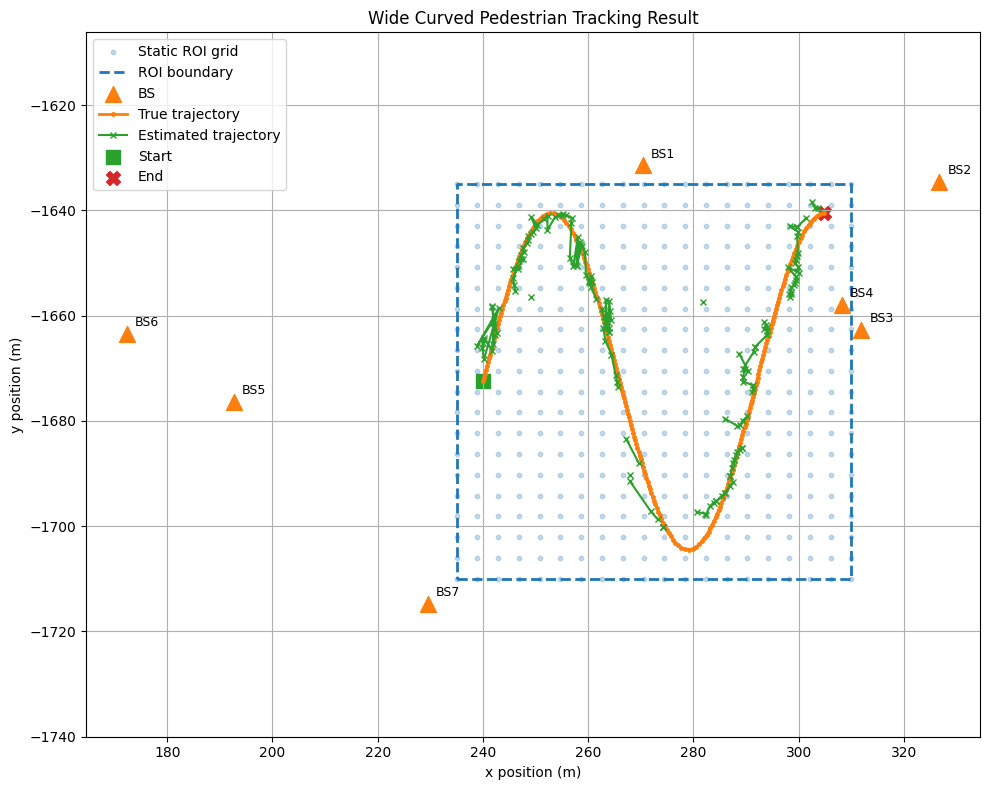

In [33]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load tracking result
# ============================================================

tracking_file = "/home/yerim/isac_tracking_wide_curved_result.pkl"

with open(tracking_file, "rb") as f:
    data = pickle.load(f)

results = data["trajectory_results"]
true_traj = np.array(data["true_trajectory"])
all_bs = np.array(data["all_bs"])

roi = data.get("ROI", None)

if roi is not None:
    X_MIN = roi["X_MIN"]
    X_MAX = roi["X_MAX"]
    Y_MIN = roi["Y_MIN"]
    Y_MAX = roi["Y_MAX"]
else:
    X_MIN, X_MAX = 235.0, 310.0
    Y_MIN, Y_MAX = -1710.0, -1635.0

# ============================================================
# Mild jump filtering for visualization
# ============================================================

VIS_JUMP_THRESH = 12.0   # m
MAX_DT_FOR_JUMP = 1.0    # s

pred_vis = []
cleaned_results = []
removed_points = []

prev_valid_pred = None
prev_valid_time = None

for r in results:
    pred = r["pred_pos"]
    err = r["error"]
    cur_time = r["time"]

    if pred is None or err is None:
        pred_vis.append([np.nan, np.nan])
        cleaned_results.append({
            **r,
            "pred_pos": None,
            "error": None,
            "outlier_reason": "no_bs"
        })
        continue

    pred_np = np.array(pred)

    remove = False
    reason = None

    if prev_valid_pred is not None:
        dt_gap = cur_time - prev_valid_time
        jump = np.linalg.norm(pred_np - prev_valid_pred)

        # 핵심: 짧은 시간 안에 크게 튄 경우만 제거
        if dt_gap <= MAX_DT_FOR_JUMP and jump > VIS_JUMP_THRESH:
            remove = True
            reason = f"short_jump_{jump:.1f}m_dt_{dt_gap:.1f}s"

    if remove:
        pred_vis.append([np.nan, np.nan])
        removed_points.append({
            "time": cur_time,
            "pred_pos": pred,
            "true_pos": r["true_pos"],
            "error": err,
            "jump": jump,
            "dt_gap": dt_gap,
            "n_bs": r["n_bs"]
        })
        cleaned_results.append({
            **r,
            "pred_pos": None,
            "error": None,
            "outlier_reason": reason
        })
        # prev_valid_pred 업데이트 안 함
        continue

    pred_vis.append(pred)
    cleaned_results.append({
        **r,
        "outlier_reason": None
    })

    prev_valid_pred = pred_np
    prev_valid_time = cur_time

pred_vis = np.array(pred_vis)

# ============================================================
# Statistics
# ============================================================

orig_errors = np.array([
    r["error"] for r in results
    if r["error"] is not None
])

clean_errors = np.array([
    r["error"] for r in cleaned_results
    if r["error"] is not None
])

print("=" * 70)
print("Mild Tracking Jump Filtering")
print("=" * 70)
print(f"VIS_JUMP_THRESH = {VIS_JUMP_THRESH:.1f} m")
print(f"MAX_DT_FOR_JUMP = {MAX_DT_FOR_JUMP:.1f} s")
print(f"원본 유효 샘플:      {len(orig_errors)}/{len(results)}")
print(f"제거된 jump outlier: {len(removed_points)}")
print(f"정제 후 유효 샘플:   {len(clean_errors)}/{len(results)}")

print("\n제거된 점들:")
for i, p in enumerate(removed_points):
    print(
        f"{i+1}: t={p['time']:.1f}s | "
        f"jump={p['jump']:.2f}m | "
        f"dt={p['dt_gap']:.1f}s | "
        f"error={p['error']:.2f}m | "
        f"BS={p['n_bs']} | "
        f"pred={np.round(p['pred_pos'], 2)}"
    )

print("\n[Original]")
print(f"Median: {np.median(orig_errors):.2f} m")
print(f"RMSE:   {np.sqrt(np.mean(orig_errors**2)):.2f} m")
print(f"P90:    {np.percentile(orig_errors, 90):.2f} m")
print(f"Max:    {np.max(orig_errors):.2f} m")
print(f"<10m:   {np.mean(orig_errors < 10) * 100:.1f}%")

print("\n[Cleaned]")
print(f"Median: {np.median(clean_errors):.2f} m")
print(f"RMSE:   {np.sqrt(np.mean(clean_errors**2)):.2f} m")
print(f"P90:    {np.percentile(clean_errors, 90):.2f} m")
print(f"Max:    {np.max(clean_errors):.2f} m")
print(f"<10m:   {np.mean(clean_errors < 10) * 100:.1f}%")

# ============================================================
# Save cleaned version
# ============================================================

data["trajectory_results_cleaned_mild"] = cleaned_results
data["visualization_outlier_rule"] = {
    "type": "short_time_jump",
    "VIS_JUMP_THRESH": VIS_JUMP_THRESH,
    "MAX_DT_FOR_JUMP": MAX_DT_FOR_JUMP,
    "criterion": "remove if dt_gap <= 1.0 s and jump > 12 m"
}

with open("/home/yerim/isac_tracking_wide_curved_cleaned_mild.pkl", "wb") as f:
    pickle.dump(data, f)

print("\n✅ 저장 완료: /home/yerim/isac_tracking_wide_curved_cleaned_mild.pkl")

# ============================================================
# Plot
# ============================================================

x_range = np.linspace(X_MIN, X_MAX, 20)
y_range = np.linspace(Y_MIN, Y_MAX, 20)
X, Y = np.meshgrid(x_range, y_range)

plt.figure(figsize=(10, 8))

plt.scatter(
    X.flatten(),
    Y.flatten(),
    s=10,
    alpha=0.25,
    label="Static ROI grid"
)

plt.plot(
    [X_MIN, X_MAX, X_MAX, X_MIN, X_MIN],
    [Y_MIN, Y_MIN, Y_MAX, Y_MAX, Y_MIN],
    linestyle="--",
    linewidth=2,
    label="ROI boundary"
)

plt.scatter(
    all_bs[:, 0],
    all_bs[:, 1],
    marker="^",
    s=130,
    label="BS"
)

for i, bs in enumerate(all_bs):
    plt.text(bs[0] + 1.5, bs[1] + 1.5, f"BS{i+1}", fontsize=9)

plt.plot(
    true_traj[:, 0],
    true_traj[:, 1],
    marker="o",
    markersize=2.5,
    linewidth=2,
    label="True trajectory"
)

plt.plot(
    pred_vis[:, 0],
    pred_vis[:, 1],
    marker="x",
    markersize=4,
    linewidth=1.5,
    label="Estimated trajectory"
)

plt.scatter(
    true_traj[0, 0],
    true_traj[0, 1],
    marker="s",
    s=90,
    label="Start"
)

plt.scatter(
    true_traj[-1, 0],
    true_traj[-1, 1],
    marker="X",
    s=100,
    label="End"
)

plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.title("Wide Curved Pedestrian Tracking Result")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
import pickle
import numpy as np

# ============================================================
# Tracking jump outlier 제거 후 오차율 계산
# ============================================================

tracking_file = "/home/yerim/isac_tracking_wide_curved_result.pkl"

with open(tracking_file, "rb") as f:
    data = pickle.load(f)

results = data["trajectory_results"]

# ============================================================
# Outlier 기준
# ============================================================
VIS_JUMP_THRESH = 12.0   # m, 짧은 시간 내 12m 이상 튀면 outlier
MAX_DT_FOR_JUMP = 1.0    # s, 1초 이하 간격에서만 jump 기준 적용

print("=" * 70)
print("Tracking jump outlier 제거 후 성능 계산")
print("=" * 70)
print(f"Jump threshold: {VIS_JUMP_THRESH:.1f} m")
print(f"Max dt for jump filtering: {MAX_DT_FOR_JUMP:.1f} s")

# ============================================================
# Original errors
# ============================================================
orig_errors = np.array([
    r["error"] for r in results
    if r["error"] is not None
])

# ============================================================
# Jump outlier filtering
# ============================================================
cleaned_results = []
removed_outliers = []

prev_valid_pred = None
prev_valid_time = None

for r in results:
    pred = r["pred_pos"]
    err = r["error"]
    cur_time = r["time"]

    # 추정 불가인 경우
    if pred is None or err is None:
        cleaned_results.append({
            **r,
            "pred_pos": None,
            "error": None,
            "outlier_reason": "no_bs"
        })
        continue

    pred_np = np.array(pred)

    remove = False
    reason = None

    if prev_valid_pred is not None:
        dt_gap = cur_time - prev_valid_time
        jump = np.linalg.norm(pred_np - prev_valid_pred)

        # 짧은 시간 내 큰 jump만 제거
        if dt_gap <= MAX_DT_FOR_JUMP and jump > VIS_JUMP_THRESH:
            remove = True
            reason = f"jump_{jump:.2f}m_dt_{dt_gap:.1f}s"

    if remove:
        removed_outliers.append({
            "time": cur_time,
            "true_pos": r["true_pos"],
            "pred_pos": pred,
            "error": err,
            "jump": jump,
            "dt_gap": dt_gap,
            "n_bs": r["n_bs"],
            "reason": reason
        })

        cleaned_results.append({
            **r,
            "pred_pos": None,
            "error": None,
            "outlier_reason": reason
        })

        # outlier는 이전 유효 위치로 업데이트하지 않음
        continue

    # 정상 추정값
    cleaned_results.append({
        **r,
        "outlier_reason": None
    })

    prev_valid_pred = pred_np
    prev_valid_time = cur_time

# ============================================================
# Cleaned errors
# ============================================================
clean_errors = np.array([
    r["error"] for r in cleaned_results
    if r["error"] is not None
])

# ============================================================
# Statistics function
# ============================================================
def print_stats(name, errors, total_steps):
    print(f"\n[{name}]")
    print(f"유효 샘플:   {len(errors)}/{total_steps} ({len(errors)/total_steps*100:.1f}%)")
    print(f"평균 오차:   {np.mean(errors):.2f} m")
    print(f"중앙값:      {np.median(errors):.2f} m")
    print(f"RMSE:        {np.sqrt(np.mean(errors**2)):.2f} m")
    print(f"P90:         {np.percentile(errors, 90):.2f} m")
    print(f"Max:         {np.max(errors):.2f} m")
    print(f"< 1m:        {np.mean(errors < 1)*100:.1f}%")
    print(f"< 2m:        {np.mean(errors < 2)*100:.1f}%")
    print(f"< 5m:        {np.mean(errors < 5)*100:.1f}%")
    print(f"< 10m:       {np.mean(errors < 10)*100:.1f}%")

# ============================================================
# Print results
# ============================================================
total_steps = len(results)

print(f"\n전체 step:             {total_steps}")
print(f"원본 유효 step:        {len(orig_errors)}")
print(f"제거된 jump outlier:   {len(removed_outliers)}")
print(f"정제 후 유효 step:     {len(clean_errors)}")

print_stats("Original Tracking", orig_errors, total_steps)
print_stats("Jump-filtered Tracking", clean_errors, total_steps)

# ============================================================
# Removed outlier list
# ============================================================
print("\n제거된 jump outlier 목록")
print("-" * 70)

for i, p in enumerate(removed_outliers):
    print(
        f"{i+1:2d}: "
        f"t={p['time']:6.1f}s | "
        f"jump={p['jump']:6.2f}m | "
        f"dt={p['dt_gap']:4.1f}s | "
        f"error={p['error']:6.2f}m | "
        f"BS={p['n_bs']} | "
        f"true={np.round(p['true_pos'], 2)} | "
        f"pred={np.round(p['pred_pos'], 2)}"
    )

# ============================================================
# Save cleaned result
# ============================================================
data["trajectory_results_cleaned_jump12"] = cleaned_results
data["tracking_outlier_rule"] = {
    "type": "short_time_large_jump",
    "jump_threshold_m": VIS_JUMP_THRESH,
    "max_dt_for_jump_s": MAX_DT_FOR_JUMP,
    "criterion": "remove if dt_gap <= 1.0 s and jump > 12 m"
}

save_file = "/home/yerim/isac_tracking_wide_curved_cleaned_jump12.pkl"

with open(save_file, "wb") as f:
    pickle.dump(data, f)

print(f"\n✅ 저장 완료: {save_file}")

Tracking jump outlier 제거 후 성능 계산
Jump threshold: 12.0 m
Max dt for jump filtering: 1.0 s

전체 step:             237
원본 유효 step:        175
제거된 jump outlier:   8
정제 후 유효 step:     167

[Original Tracking]
유효 샘플:   175/237 (73.8%)
평균 오차:   3.31 m
중앙값:      1.87 m
RMSE:        5.47 m
P90:         8.26 m
Max:         23.27 m
< 1m:        20.6%
< 2m:        55.4%
< 5m:        84.0%
< 10m:       93.1%

[Jump-filtered Tracking]
유효 샘플:   167/237 (70.5%)
평균 오차:   2.71 m
중앙값:      1.83 m
RMSE:        4.05 m
P90:         5.85 m
Max:         22.58 m
< 1m:        21.6%
< 2m:        57.5%
< 5m:        86.8%
< 10m:       96.4%

제거된 jump outlier 목록
----------------------------------------------------------------------
 1: t=  49.5s | jump= 14.72m | dt= 0.5s | error= 16.95m | BS=3 | true=[  266.84 -1675.75] | pred=[  265.41 -1658.86]
 2: t=  86.5s | jump= 24.28m | dt= 0.5s | error= 23.27m | BS=5 | true=[  288.92 -1684.14] | pred=[  277.07 -1664.12]
 3: t=  89.5s | jump= 20.35m | dt= 0.5s | error= 20.87m

In [1]:
import pickle
import numpy as np

tracking_file = "/home/yerim/isac_tracking_wide_curved_result.pkl"

with open(tracking_file, "rb") as f:
    data = pickle.load(f)

results = data["trajectory_results"]

# Tracking과 Static에 동일하게 쓴 ROI
X_MIN, X_MAX = 235.0, 310.0
Y_MIN, Y_MAX = -1710.0, -1635.0

orig_errors = []
clean_errors = []
cleaned_results = []

n_no_bs = 0
n_outside = 0

for r in results:
    pred = r["pred_pos"]
    err = r["error"]

    if pred is None or err is None:
        n_no_bs += 1
        cleaned_results.append({
            **r,
            "pred_pos": None,
            "error": None,
            "outlier_reason": "no_bs"
        })
        continue

    orig_errors.append(err)

    outside_roi = (
        pred[0] < X_MIN or pred[0] > X_MAX or
        pred[1] < Y_MIN or pred[1] > Y_MAX
    )

    if outside_roi:
        n_outside += 1
        cleaned_results.append({
            **r,
            "pred_pos": None,
            "error": None,
            "outlier_reason": "outside_roi"
        })
        continue

    clean_errors.append(err)
    cleaned_results.append({
        **r,
        "outlier_reason": None
    })

orig_errors = np.array(orig_errors)
clean_errors = np.array(clean_errors)

print("=" * 70)
print("Tracking ROI-only filtering result")
print("=" * 70)

print(f"전체 step:             {len(results)}")
print(f"추정 불가 step:        {n_no_bs}")
print(f"원본 유효 step:        {len(orig_errors)}/{len(results)}")
print(f"ROI 밖 예측 제거:      {n_outside}")
print(f"ROI 정제 후 유효 step: {len(clean_errors)}/{len(results)}")

print("\n[Original Tracking]")
print(f"Mean:   {np.mean(orig_errors):.2f} m")
print(f"Median: {np.median(orig_errors):.2f} m")
print(f"RMSE:   {np.sqrt(np.mean(orig_errors**2)):.2f} m")
print(f"P90:    {np.percentile(orig_errors, 90):.2f} m")
print(f"Max:    {np.max(orig_errors):.2f} m")
print(f"<10m:   {np.mean(orig_errors < 10) * 100:.1f}%")

print("\n[ROI-filtered Tracking]")
print(f"Mean:   {np.mean(clean_errors):.2f} m")
print(f"Median: {np.median(clean_errors):.2f} m")
print(f"RMSE:   {np.sqrt(np.mean(clean_errors**2)):.2f} m")
print(f"P90:    {np.percentile(clean_errors, 90):.2f} m")
print(f"Max:    {np.max(clean_errors):.2f} m")
print(f"<10m:   {np.mean(clean_errors < 10) * 100:.1f}%")

data["trajectory_results_roi_filtered"] = cleaned_results
data["outlier_rule_roi_only"] = {
    "type": "outside_roi_only",
    "X_MIN": X_MIN,
    "X_MAX": X_MAX,
    "Y_MIN": Y_MIN,
    "Y_MAX": Y_MAX,
    "criterion": "predicted position outside ROI"
}

save_file = "/home/yerim/isac_tracking_wide_curved_roi_filtered.pkl"

with open(save_file, "wb") as f:
    pickle.dump(data, f)

print(f"\n✅ 저장 완료: {save_file}")

Tracking ROI-only filtering result
전체 step:             237
추정 불가 step:        62
원본 유효 step:        175/237
ROI 밖 예측 제거:      1
ROI 정제 후 유효 step: 174/237

[Original Tracking]
Mean:   3.31 m
Median: 1.87 m
RMSE:   5.47 m
P90:    8.26 m
Max:    23.27 m
<10m:   93.1%

[ROI-filtered Tracking]
Mean:   3.22 m
Median: 1.86 m
RMSE:   5.27 m
P90:    7.88 m
Max:    23.27 m
<10m:   93.7%

✅ 저장 완료: /home/yerim/isac_tracking_wide_curved_roi_filtered.pkl


In [5]:
import pickle
import numpy as np

# ============================================================
# 최종 파일 경로
# ============================================================

static_file = "/home/yerim/isac_static_wide_400_cleaned_roi_only.pkl"
tracking_file = "/home/yerim/isac_tracking_wide_curved_roi_filtered.pkl"

# ============================================================
# Load Static
# ============================================================

with open(static_file, "rb") as f:
    static_data = pickle.load(f)

print("Static keys:", static_data.keys())

static_results = static_data["dataset"]

static_errors = []

for r in static_results:
    if r.get("error") is not None:
        static_errors.append(r["error"])

static_errors = np.array(static_errors)

# ============================================================
# Load Tracking
# ============================================================

with open(tracking_file, "rb") as f:
    tracking_data = pickle.load(f)

print("Tracking keys:", tracking_data.keys())

if "trajectory_results_roi_filtered" in tracking_data:
    tracking_results = tracking_data["trajectory_results_roi_filtered"]
elif "trajectory_results" in tracking_data:
    tracking_results = tracking_data["trajectory_results"]
else:
    raise KeyError("Tracking result key를 못 찾음:", tracking_data.keys())

tracking_errors = []

for r in tracking_results:
    if r.get("error") is not None:
        tracking_errors.append(r["error"])

tracking_errors = np.array(tracking_errors)

# ============================================================
# m별 누적 오차율 계산
# ============================================================

thresholds = np.arange(1, 11, 1)  # 1m ~ 10m

print("\n" + "=" * 70)
print("m별 누적 오차율 결과")
print("=" * 70)
print(f"{'Error threshold':<18} | {'Static Wide ROI (%)':>20} | {'Curved Tracking (%)':>22}")
print("-" * 70)

table_rows = []

for th in thresholds:
    static_ratio = np.mean(static_errors <= th) * 100
    tracking_ratio = np.mean(tracking_errors <= th) * 100

    table_rows.append((th, static_ratio, tracking_ratio))

    print(f"≤ {th:<15} | {static_ratio:>20.1f} | {tracking_ratio:>22.1f}")

# ============================================================
# Summary
# ============================================================

def print_summary(name, errors, total):
    print("\n" + f"[{name}]")
    print(f"Valid samples: {len(errors)}/{total} ({len(errors)/total*100:.1f}%)")
    print(f"Median:        {np.median(errors):.2f} m")
    print(f"Mean:          {np.mean(errors):.2f} m")
    print(f"RMSE:          {np.sqrt(np.mean(errors**2)):.2f} m")
    print(f"P90:           {np.percentile(errors, 90):.2f} m")
    print(f"Max:           {np.max(errors):.2f} m")
    print(f"≤ 1m:          {np.mean(errors <= 1)*100:.1f}%")
    print(f"≤ 2m:          {np.mean(errors <= 2)*100:.1f}%")
    print(f"≤ 5m:          {np.mean(errors <= 5)*100:.1f}%")
    print(f"≤ 10m:         {np.mean(errors <= 10)*100:.1f}%")

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)

print_summary("Static Wide ROI", static_errors, total=400)
print_summary("Curved Tracking", tracking_errors, total=237)

# ============================================================
# CSV 직접 저장
# ============================================================

save_csv = "/home/yerim/error_threshold_table.csv"

with open(save_csv, "w") as f:
    f.write("Error threshold (m),Static Wide ROI (%),Curved Tracking (%)\n")
    for th, s_ratio, t_ratio in table_rows:
        f.write(f"{th},{s_ratio:.1f},{t_ratio:.1f}\n")

print(f"\n✅ CSV 저장 완료: {save_csv}")

Static keys: dict_keys(['dataset', 'errors', 'valid_bs_counts', 'all_bs', 'BS_Z', 'TARGET_Z', 'x_range', 'y_range', 'X_MIN', 'X_MAX', 'Y_MIN', 'Y_MAX', 'CLUTTER_THRESH', 'MAX_RANGE_HORIZ', 'outlier_rule'])
Tracking keys: dict_keys(['true_trajectory', 'true_velocities', 'trajectory_results', 'all_bs', 'walking_speed', 'duration', 'dt', 'BS_Z', 'TARGET_Z', 'carrier_freq', 'MIN_BS', 'CLUTTER_THRESH', 'MAX_RANGE_HORIZ', 'MOTION_WEIGHT', 'JUMP_THRESHOLD', 'ROI', 'trajectory_type', 'trajectory_results_roi_filtered', 'outlier_rule_roi_only'])

m별 누적 오차율 결과
Error threshold    |  Static Wide ROI (%) |    Curved Tracking (%)
----------------------------------------------------------------------
≤ 1               |                 18.0 |                   20.7
≤ 2               |                 50.0 |                   55.7
≤ 3               |                 64.0 |                   76.4
≤ 4               |                 68.7 |                   80.5
≤ 5               |                 71.9 |